In [ ]:
import matplotlib.pyplot as plt
import numpy as np

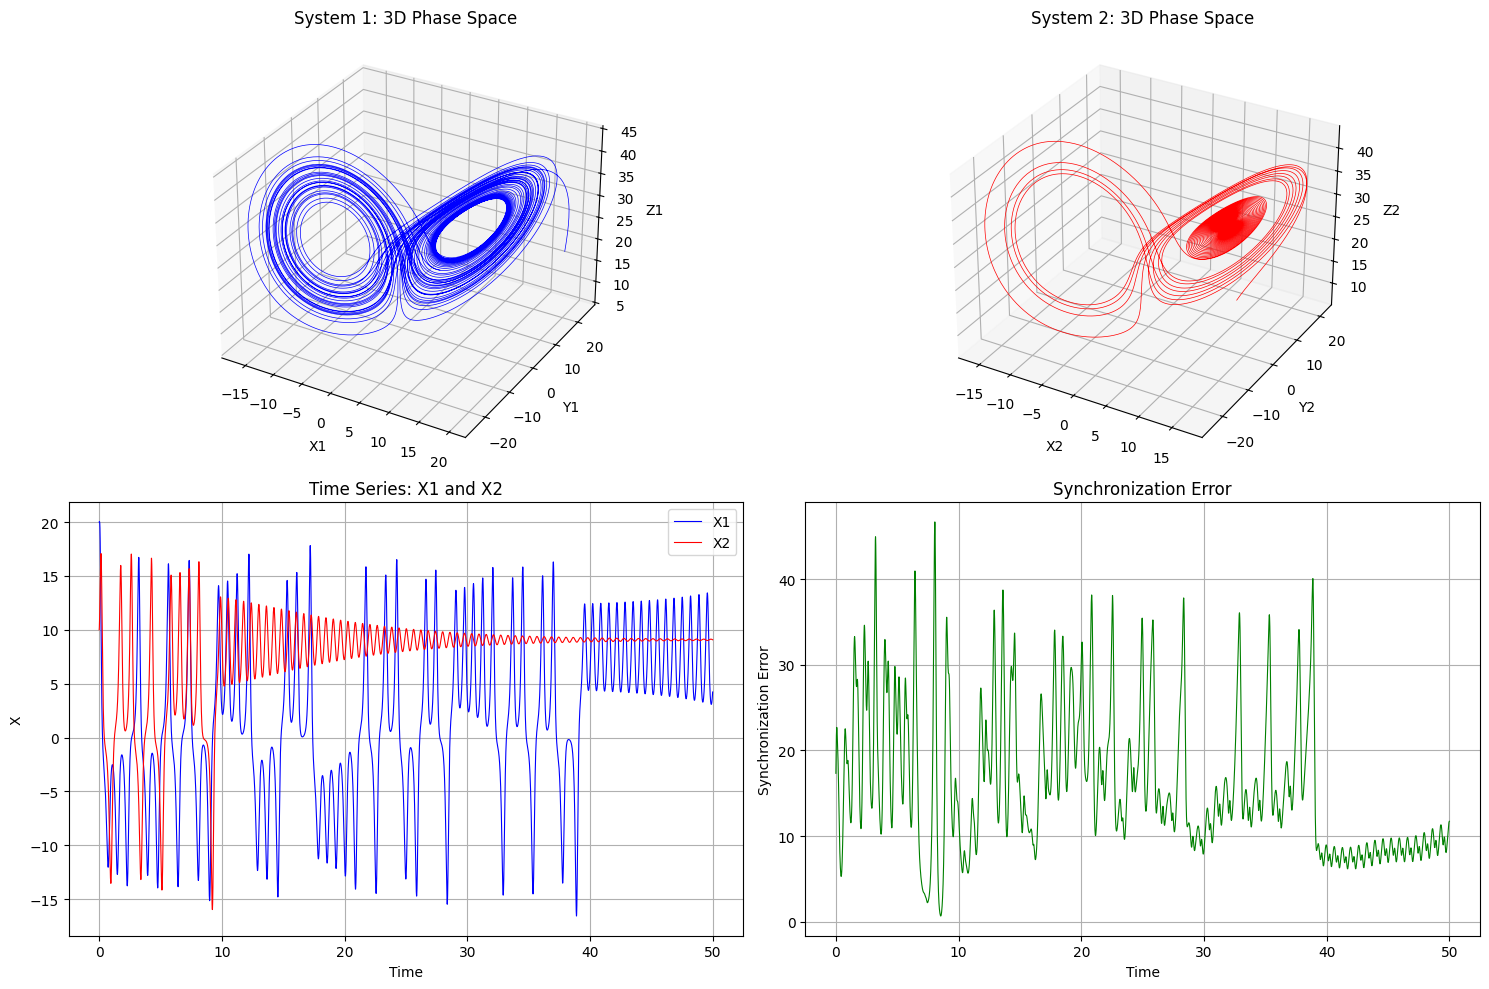

Simulation completed for 20000 steps
Time delay steps: 20000
Final synchronization error: 11.7226


In [ ]:
#2 Diffusively coupled lorenz equations with time delay
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parameters
s = 10
b = 8/3
r = 28
e = 1
t0 = 0
tf = 50
N = 20000
h = (tf - t0) / N
tau = 50
time_delaysteps = int(tau / h)

# Derivative functions for system 1
def dx1(s, x1_curr, y1_curr, x2_delayed, e):
    return s * (y1_curr - x1_curr) + e * (x2_delayed - x1_curr)

def dy1(r, x1_curr, z1_curr, y1_curr):
    return x1_curr * (r - z1_curr) - y1_curr

def dz1(b, x1_curr, y1_curr, z1_curr):
    return x1_curr * y1_curr - b * z1_curr

# Derivative functions for system 2
def dx2(s, x2_curr, y2_curr, x1_delayed, e):
    return s * (y2_curr - x2_curr) + e * (x1_delayed - x2_curr)

def dy2(r, x2_curr, z2_curr, y2_curr):
    return x2_curr * (r - z2_curr) - y2_curr

def dz2(b, x2_curr, y2_curr, z2_curr):
    return x2_curr * y2_curr - b * z2_curr

# Function to get delayed value
def get_delayed_value(history, time_delaysteps, current_idx):
    idx = current_idx - time_delaysteps
    if idx < 0:
        return history[0]
    else:
        return history[idx]

# RK4 method
def rk4(t0, x10, y10, z10, x20, y20, z20):
    x1_hist = [x10]
    y1_hist = [y10]
    z1_hist = [z10]
    x2_hist = [x20]
    y2_hist = [y20]
    z2_hist = [z20]
    t_hist = [t0]

    x1_curr = x10
    y1_curr = y10
    z1_curr = z10
    x2_curr = x20
    y2_curr = y20
    z2_curr = z20
    t_curr = t0

    for i in range(N):
        # Get delayed values
        x1_delayed = get_delayed_value(x1_hist, time_delaysteps, i)
        x2_delayed = get_delayed_value(x2_hist, time_delaysteps, i)

        # K1 calculations
        k1x1 = h * dx1(s, x1_curr, y1_curr, x2_delayed, e)
        k1y1 = h * dy1(r, x1_curr, z1_curr, y1_curr)
        k1z1 = h * dz1(b, x1_curr, y1_curr, z1_curr)
        k1x2 = h * dx2(s, x2_curr, y2_curr, x1_delayed, e)
        k1y2 = h * dy2(r, x2_curr, z2_curr, y2_curr)
        k1z2 = h * dz2(b, x2_curr, y2_curr, z2_curr)

        # K2 calculations
        k2x1 = h * dx1(s, x1_curr + k1x1/2, y1_curr + k1y1/2, x2_delayed, e)
        k2y1 = h * dy1(r, x1_curr + k1x1/2, z1_curr + k1z1/2, y1_curr + k1y1/2)
        k2z1 = h * dz1(b, x1_curr + k1x1/2, y1_curr + k1y1/2, z1_curr + k1z1/2)
        k2x2 = h * dx2(s, x2_curr + k1x2/2, y2_curr + k1y2/2, x1_delayed, e)
        k2y2 = h * dy2(r, x2_curr + k1x2/2, z2_curr + k1z2/2, y2_curr + k1y2/2)
        k2z2 = h * dz2(b, x2_curr + k1x2/2, y2_curr + k1y2/2, z2_curr + k1z2/2)

        # K3 calculations
        k3x1 = h * dx1(s, x1_curr + k2x1/2, y1_curr + k2y1/2, x2_delayed, e)
        k3y1 = h * dy1(r, x1_curr + k2x1/2, z1_curr + k2z1/2, y1_curr + k2y1/2)
        k3z1 = h * dz1(b, x1_curr + k2x1/2, y1_curr + k2y1/2, z1_curr + k2z1/2)
        k3x2 = h * dx2(s, x2_curr + k2x2/2, y2_curr + k2y2/2, x1_delayed, e)
        k3y2 = h * dy2(r, x2_curr + k2x2/2, z2_curr + k2z2/2, y2_curr + k2y2/2)
        k3z2 = h * dz2(b, x2_curr + k2x2/2, y2_curr + k2y2/2, z2_curr + k2z2/2)

        # K4 calculations
        k4x1 = h * dx1(s, x1_curr + k3x1, y1_curr + k3y1, x2_delayed, e)
        k4y1 = h * dy1(r, x1_curr + k3x1, z1_curr + k3z1, y1_curr + k3y1)
        k4z1 = h * dz1(b, x1_curr + k3x1, y1_curr + k3y1, z1_curr + k3z1)
        k4x2 = h * dx2(s, x2_curr + k3x2, y2_curr + k3y2, x1_delayed, e)
        k4y2 = h * dy2(r, x2_curr + k3x2, z2_curr + k3z2, y2_curr + k3y2)
        k4z2 = h * dz2(b, x2_curr + k3x2, y2_curr + k3y2, z2_curr + k3z2)

        # Update values
        x1_curr = x1_curr + (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1_curr = y1_curr + (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1_curr = z1_curr + (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6
        x2_curr = x2_curr + (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2_curr = y2_curr + (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2_curr = z2_curr + (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6
        t_curr = t_curr + h

        # Store history
        x1_hist.append(x1_curr)
        y1_hist.append(y1_curr)
        z1_hist.append(z1_curr)
        x2_hist.append(x2_curr)
        y2_hist.append(y2_curr)
        z2_hist.append(z2_curr)
        t_hist.append(t_curr)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist), np.array(t_hist)

# Initial conditions
x10, y10, z10 = 20, 20, 20
x20, y20, z20 = 10, 10, 10

# Run simulation
x1, y1, z1, x2, y2, z2, t = rk4(t0, x10, y10, z10, x20, y20, z20)

# Plotting
fig = plt.figure(figsize=(15, 10))

# 3D plot for System 1
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(x1, y1, z1, 'b-', linewidth=0.5)
ax1.set_xlabel('X1')
ax1.set_ylabel('Y1')
ax1.set_zlabel('Z1')
ax1.set_title('System 1: 3D Phase Space')

# 3D plot for System 2
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot(x2, y2, z2, 'r-', linewidth=0.5)
ax2.set_xlabel('X2')
ax2.set_ylabel('Y2')
ax2.set_zlabel('Z2')
ax2.set_title('System 2: 3D Phase Space')

# Time series of X1 and X2
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(t, x1, 'b-', label='X1', linewidth=0.8)
ax3.plot(t, x2, 'r-', label='X2', linewidth=0.8)
ax3.set_xlabel('Time')
ax3.set_ylabel('X')
ax3.set_title('Time Series: X1 and X2')
ax3.legend()
ax3.grid(True)

# Synchronization error
ax4 = fig.add_subplot(2, 2, 4)
sync_error = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)
ax4.plot(t, sync_error, 'g-', linewidth=0.8)
ax4.set_xlabel('Time')
ax4.set_ylabel('Synchronization Error')
ax4.set_title('Synchronization Error')
ax4.grid(True)

plt.tight_layout()
plt.show()

print(f"Simulation completed for {N} steps")
print(f"Time delay steps: {time_delaysteps}")
print(f"Final synchronization error: {sync_error[-1]:.4f}")

Running Lorenz simulation with time delay...
Running Lorenz simulation without time delay...


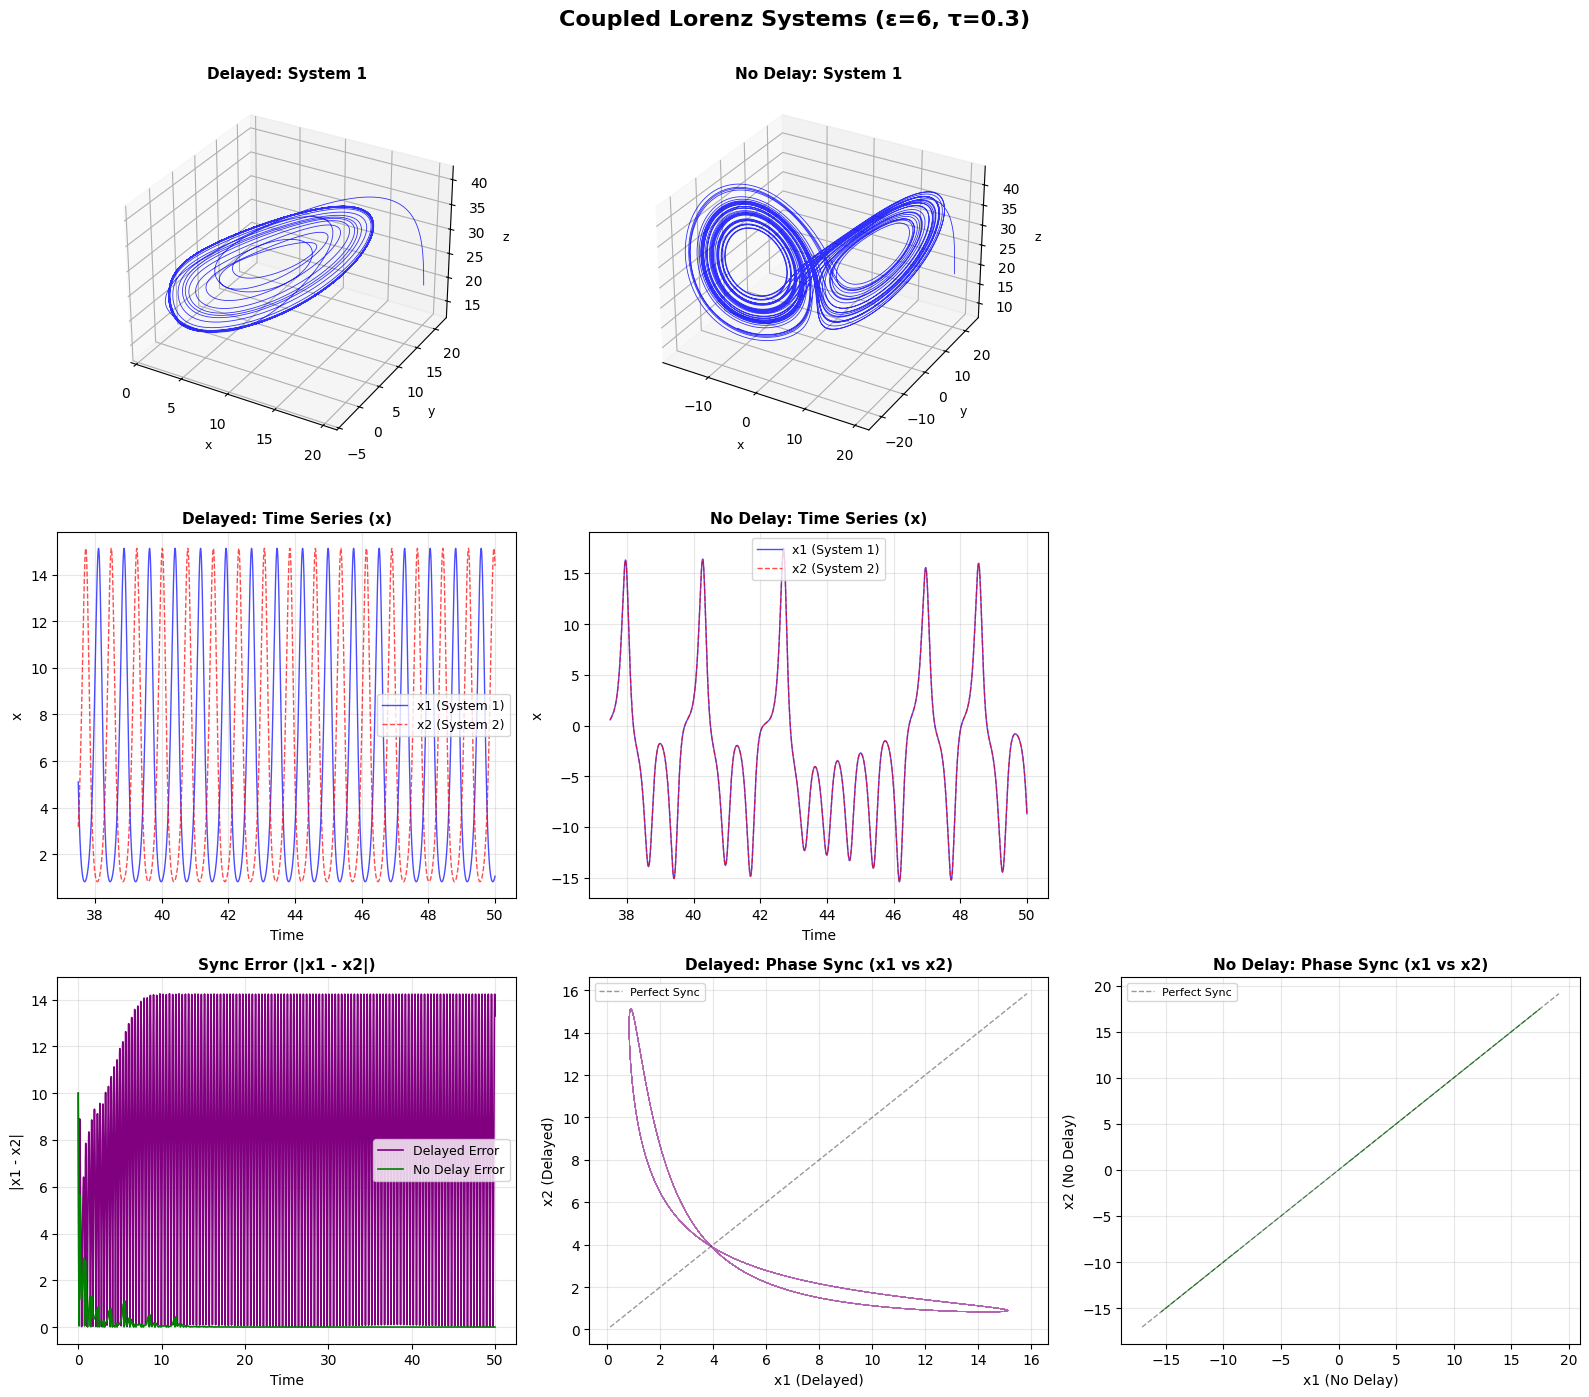


LORENZ SIMULATION RESULTS
Coupling Strength (ε): 6
Time Delay (τ): 0.3
Simulation Time: 0 to 50
Number of Steps: 20000
Time Delay Steps: 120

Final Synchronization Error:
  With Delay:    13.305448
  Without Delay: 0.000000

Mean Synchronization Error:
  With Delay:    7.983783
  Without Delay: 0.108202


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Parameters for Lorenz System
# ==========================================
s = 10
b = 8/3
r = 28
e = 6
t0 = 0
tf = 50
N = 20000
h = (tf - t0) / N
tau = 0.3
time_delaysteps = int(tau / h)

# ==========================================
# 2. Derivative Functions
# ==========================================

# Derivative functions for system 1
def dx1(s, x1_curr, y1_curr, x2_delayed, e):
    return s * (y1_curr - x1_curr) + e * (x2_delayed - x1_curr)

def dy1(r, x1_curr, z1_curr, y1_curr):
    return x1_curr * (r - z1_curr) - y1_curr

def dz1(b, x1_curr, y1_curr, z1_curr):
    return x1_curr * y1_curr - b * z1_curr

# Derivative functions for system 2
def dx2(s, x2_curr, y2_curr, x1_delayed, e):
    return s * (y2_curr - x2_curr) + e * (x1_delayed - x2_curr)

def dy2(r, x2_curr, z2_curr, y2_curr):
    return x2_curr * (r - z2_curr) - y2_curr

def dz2(b, x2_curr, y2_curr, z2_curr):
    return x2_curr * y2_curr - b * z2_curr

# ==========================================
# 3. Helper Functions
# ==========================================

def get_delayed_value(history, time_delaysteps, current_idx):
    idx = current_idx - time_delaysteps
    if idx < 0:
        return history[0]
    else:
        return history[idx]

# ==========================================
# 4. RK4 Solvers
# ==========================================

# RK4 method with time delay
def rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps):
    x1_hist = [x10]
    y1_hist = [y10]
    z1_hist = [z10]
    x2_hist = [x20]
    y2_hist = [y20]
    z2_hist = [z20]
    t_hist = [t0]

    x1_curr = x10
    y1_curr = y10
    z1_curr = z10
    x2_curr = x20
    y2_curr = y20
    z2_curr = z20
    t_curr = t0

    for i in range(N):
        # Get delayed values
        x1_delayed = get_delayed_value(x1_hist, time_delaysteps, i)
        x2_delayed = get_delayed_value(x2_hist, time_delaysteps, i)

        # K1 calculations
        k1x1 = h * dx1(s, x1_curr, y1_curr, x2_delayed, e)
        k1y1 = h * dy1(r, x1_curr, z1_curr, y1_curr)
        k1z1 = h * dz1(b, x1_curr, y1_curr, z1_curr)
        k1x2 = h * dx2(s, x2_curr, y2_curr, x1_delayed, e)
        k1y2 = h * dy2(r, x2_curr, z2_curr, y2_curr)
        k1z2 = h * dz2(b, x2_curr, y2_curr, z2_curr)

        # K2 calculations
        k2x1 = h * dx1(s, x1_curr + k1x1/2, y1_curr + k1y1/2, x2_delayed, e)
        k2y1 = h * dy1(r, x1_curr + k1x1/2, z1_curr + k1z1/2, y1_curr + k1y1/2)
        k2z1 = h * dz1(b, x1_curr + k1x1/2, y1_curr + k1y1/2, z1_curr + k1z1/2)
        k2x2 = h * dx2(s, x2_curr + k1x2/2, y2_curr + k1y2/2, x1_delayed, e)
        k2y2 = h * dy2(r, x2_curr + k1x2/2, z2_curr + k1z2/2, y2_curr + k1y2/2)
        k2z2 = h * dz2(b, x2_curr + k1x2/2, y2_curr + k1y2/2, z2_curr + k1z2/2)

        # K3 calculations
        k3x1 = h * dx1(s, x1_curr + k2x1/2, y1_curr + k2y1/2, x2_delayed, e)
        k3y1 = h * dy1(r, x1_curr + k2x1/2, z1_curr + k2z1/2, y1_curr + k2y1/2)
        k3z1 = h * dz1(b, x1_curr + k2x1/2, y1_curr + k2y1/2, z1_curr + k2z1/2)
        k3x2 = h * dx2(s, x2_curr + k2x2/2, y2_curr + k2y2/2, x1_delayed, e)
        k3y2 = h * dy2(r, x2_curr + k2x2/2, z2_curr + k2z2/2, y2_curr + k2y2/2)
        k3z2 = h * dz2(b, x2_curr + k2x2/2, y2_curr + k2y2/2, z2_curr + k2z2/2)

        # K4 calculations
        k4x1 = h * dx1(s, x1_curr + k3x1, y1_curr + k3y1, x2_delayed, e)
        k4y1 = h * dy1(r, x1_curr + k3x1, z1_curr + k3z1, y1_curr + k3y1)
        k4z1 = h * dz1(b, x1_curr + k3x1, y1_curr + k3y1, z1_curr + k3z1)
        k4x2 = h * dx2(s, x2_curr + k3x2, y2_curr + k3y2, x1_delayed, e)
        k4y2 = h * dy2(r, x2_curr + k3x2, z2_curr + k3z2, y2_curr + k3y2)
        k4z2 = h * dz2(b, x2_curr + k3x2, y2_curr + k3y2, z2_curr + k3z2)

        # Update values
        x1_curr = x1_curr + (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1_curr = y1_curr + (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1_curr = z1_curr + (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6
        x2_curr = x2_curr + (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2_curr = y2_curr + (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2_curr = z2_curr + (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6
        t_curr = t_curr + h

        # Store history
        x1_hist.append(x1_curr)
        y1_hist.append(y1_curr)
        z1_hist.append(z1_curr)
        x2_hist.append(x2_curr)
        y2_hist.append(y2_curr)
        z2_hist.append(z2_curr)
        t_hist.append(t_curr)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist), np.array(t_hist)

# RK4 method without time delay (instantaneous coupling)
def rk4_no_delay(t0, x10, y10, z10, x20, y20, z20):
    x1_hist = [x10]
    y1_hist = [y10]
    z1_hist = [z10]
    x2_hist = [x20]
    y2_hist = [y20]
    z2_hist = [z20]
    t_hist = [t0]

    x1_curr = x10
    y1_curr = y10
    z1_curr = z10
    x2_curr = x20
    y2_curr = y20
    z2_curr = z20
    t_curr = t0

    for i in range(N):
        # No delay - use current values
        x1_instant = x1_curr
        x2_instant = x2_curr

        # K1 calculations
        k1x1 = h * dx1(s, x1_curr, y1_curr, x2_instant, e)
        k1y1 = h * dy1(r, x1_curr, z1_curr, y1_curr)
        k1z1 = h * dz1(b, x1_curr, y1_curr, z1_curr)
        k1x2 = h * dx2(s, x2_curr, y2_curr, x1_instant, e)
        k1y2 = h * dy2(r, x2_curr, z2_curr, y2_curr)
        k1z2 = h * dz2(b, x2_curr, y2_curr, z2_curr)

        # K2 calculations
        k2x1 = h * dx1(s, x1_curr + k1x1/2, y1_curr + k1y1/2, x2_instant, e)
        k2y1 = h * dy1(r, x1_curr + k1x1/2, z1_curr + k1z1/2, y1_curr + k1y1/2)
        k2z1 = h * dz1(b, x1_curr + k1x1/2, y1_curr + k1y1/2, z1_curr + k1z1/2)
        k2x2 = h * dx2(s, x2_curr + k1x2/2, y2_curr + k1y2/2, x1_instant, e)
        k2y2 = h * dy2(r, x2_curr + k1x2/2, z2_curr + k1z2/2, y2_curr + k1y2/2)
        k2z2 = h * dz2(b, x2_curr + k1x2/2, y2_curr + k1y2/2, z2_curr + k1z2/2)

        # K3 calculations
        k3x1 = h * dx1(s, x1_curr + k2x1/2, y1_curr + k2y1/2, x2_instant, e)
        k3y1 = h * dy1(r, x1_curr + k2x1/2, z1_curr + k2z1/2, y1_curr + k2y1/2)
        k3z1 = h * dz1(b, x1_curr + k2x1/2, y1_curr + k2y1/2, z1_curr + k2z1/2)
        k3x2 = h * dx2(s, x2_curr + k2x2/2, y2_curr + k2y2/2, x1_instant, e)
        k3y2 = h * dy2(r, x2_curr + k2x2/2, z2_curr + k2z2/2, y2_curr + k2y2/2)
        k3z2 = h * dz2(b, x2_curr + k2x2/2, y2_curr + k2y2/2, z2_curr + k2z2/2)

        # K4 calculations
        k4x1 = h * dx1(s, x1_curr + k3x1, y1_curr + k3y1, x2_instant, e)
        k4y1 = h * dy1(r, x1_curr + k3x1, z1_curr + k3z1, y1_curr + k3y1)
        k4z1 = h * dz1(b, x1_curr + k3x1, y1_curr + k3y1, z1_curr + k3z1)
        k4x2 = h * dx2(s, x2_curr + k3x2, y2_curr + k3y2, x1_instant, e)
        k4y2 = h * dy2(r, x2_curr + k3x2, z2_curr + k3z2, y2_curr + k3y2)
        k4z2 = h * dz2(b, x2_curr + k3x2, y2_curr + k3y2, z2_curr + k3z2)

        # Update values
        x1_curr = x1_curr + (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1_curr = y1_curr + (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1_curr = z1_curr + (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6
        x2_curr = x2_curr + (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2_curr = y2_curr + (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2_curr = z2_curr + (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6
        t_curr = t_curr + h

        # Store history
        x1_hist.append(x1_curr)
        y1_hist.append(y1_curr)
        z1_hist.append(z1_curr)
        x2_hist.append(x2_curr)
        y2_hist.append(y2_curr)
        z2_hist.append(z2_curr)
        t_hist.append(t_curr)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist), np.array(t_hist)

# ==========================================
# 5. Execution & Plotting
# ==========================================

# Initial conditions
x10, y10, z10 = 20, 20, 20
x20, y20, z20 = 10, 10, 10

# Run both simulations
print("Running Lorenz simulation with time delay...")
x1_delay, y1_delay, z1_delay, x2_delay, y2_delay, z2_delay, t_delay = rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps)

print("Running Lorenz simulation without time delay...")
x1_no, y1_no, z1_no, x2_no, y2_no, z2_no, t_no = rk4_no_delay(t0, x10, y10, z10, x20, y20, z20)

# Calculate synchronization errors
sync_error_delay = np.abs(x1_delay - x2_delay)
sync_error_no = np.abs(x1_no - x2_no)

# Create figure with layout: 2 top, 2 middle, 3 bottom
fig = plt.figure(figsize=(16, 14))

# ==========================================
# TOP ROW: 3D Phase Space (2 plots)
# ==========================================
# Delayed 3D Phase Space - System 1
ax1 = fig.add_subplot(3, 3, 1, projection='3d')
ax1.plot(x1_delay, y1_delay, z1_delay, 'b', lw=0.6, alpha=0.8)
ax1.set_xlabel('x', fontsize=9)
ax1.set_ylabel('y', fontsize=9)
ax1.set_zlabel('z', fontsize=9)
ax1.set_title('Delayed: System 1', fontsize=11, fontweight='bold')

# No Delay 3D Phase Space - System 1
ax2 = fig.add_subplot(3, 3, 2, projection='3d')
ax2.plot(x1_no, y1_no, z1_no, 'b', lw=0.6, alpha=0.8)
ax2.set_xlabel('x', fontsize=9)
ax2.set_ylabel('y', fontsize=9)
ax2.set_zlabel('z', fontsize=9)
ax2.set_title('No Delay: System 1', fontsize=11, fontweight='bold')

# ==========================================
# MIDDLE ROW: Time Series (2 plots)
# ==========================================
# Delayed Time Series
ax3 = fig.add_subplot(3, 3, 4)
start_time = 15000
ax3.plot(t_delay[start_time:], x1_delay[start_time:], 'b', lw=1, alpha=0.7, label='x1 (System 1)')
ax3.plot(t_delay[start_time:], x2_delay[start_time:], 'r--', lw=1, alpha=0.7, label='x2 (System 2)')
ax3.set_xlabel('Time', fontsize=10)
ax3.set_ylabel('x', fontsize=10)
ax3.set_title('Delayed: Time Series (x)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# No Delay Time Series
ax4 = fig.add_subplot(3, 3, 5)
ax4.plot(t_no[start_time:], x1_no[start_time:], 'b', lw=1, alpha=0.7, label='x1 (System 1)')
ax4.plot(t_no[start_time:], x2_no[start_time:], 'r--', lw=1, alpha=0.7, label='x2 (System 2)')
ax4.set_xlabel('Time', fontsize=10)
ax4.set_ylabel('x', fontsize=10)
ax4.set_title('No Delay: Time Series (x)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ==========================================
# BOTTOM ROW: 3 plots (Error + Phase Sync)
# ==========================================
# Synchronization Error Comparison
ax5 = fig.add_subplot(3, 3, 7)
ax5.plot(t_delay, sync_error_delay, 'purple', lw=1.2, label='Delayed Error')
ax5.plot(t_no, sync_error_no, 'green', lw=1.2, label='No Delay Error')
ax5.set_xlabel('Time', fontsize=10)
ax5.set_ylabel('|x1 - x2|', fontsize=10)
ax5.set_title('Sync Error (|x1 - x2|)', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Delayed Phase Synchronization - x1 vs x2
ax6 = fig.add_subplot(3, 3, 8)
ax6.plot(x1_delay[start_time:], x2_delay[start_time:], 'purple', lw=0.6, alpha=0.6)
ax6.set_xlabel('x1 (Delayed)', fontsize=10)
ax6.set_ylabel('x2 (Delayed)', fontsize=10)
ax6.set_title('Delayed: Phase Sync (x1 vs x2)', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)
# Add diagonal line for perfect sync
lims = [min(ax6.get_xlim()[0], ax6.get_ylim()[0]),
        max(ax6.get_xlim()[1], ax6.get_ylim()[1])]
ax6.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='Perfect Sync')
ax6.legend(fontsize=8)

# No Delay Phase Synchronization - x1 vs x2
ax7 = fig.add_subplot(3, 3, 9)
ax7.plot(x1_no[start_time:], x2_no[start_time:], 'green', lw=0.6, alpha=0.6)
ax7.set_xlabel('x1 (No Delay)', fontsize=10)
ax7.set_ylabel('x2 (No Delay)', fontsize=10)
ax7.set_title('No Delay: Phase Sync (x1 vs x2)', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3)
# Add diagonal line for perfect sync
lims = [min(ax7.get_xlim()[0], ax7.get_ylim()[0]),
        max(ax7.get_xlim()[1], ax7.get_ylim()[1])]
ax7.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='Perfect Sync')
ax7.legend(fontsize=8)

plt.suptitle(f'Coupled Lorenz Systems (ε={e}, τ={tau})',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# ==========================================
# Statistics
# ==========================================
print("\n" + "="*60)
print("LORENZ SIMULATION RESULTS")
print("="*60)
print(f"Coupling Strength (ε): {e}")
print(f"Time Delay (τ): {tau}")
print(f"Simulation Time: {t0} to {tf}")
print(f"Number of Steps: {N}")
print(f"Time Delay Steps: {time_delaysteps}")
print(f"\nFinal Synchronization Error:")
print(f"  With Delay:    {sync_error_delay[-1]:.6f}")
print(f"  Without Delay: {sync_error_no[-1]:.6f}")
print(f"\nMean Synchronization Error:")
print(f"  With Delay:    {np.mean(sync_error_delay):.6f}")
print(f"  Without Delay: {np.mean(sync_error_no):.6f}")
print("="*60)

Computing parameter space maps for Lorenz system...
Coupling range: 0.10 to 10.00
Delay range: 0.000 to 0.500
Total simulations: 1800
Progress: 100/900 (11.1%)
Progress: 200/900 (22.2%)
Progress: 300/900 (33.3%)
Progress: 400/900 (44.4%)
Progress: 500/900 (55.6%)
Progress: 600/900 (66.7%)
Progress: 700/900 (77.8%)
Progress: 800/900 (88.9%)
Progress: 900/900 (100.0%)
Simulation complete!


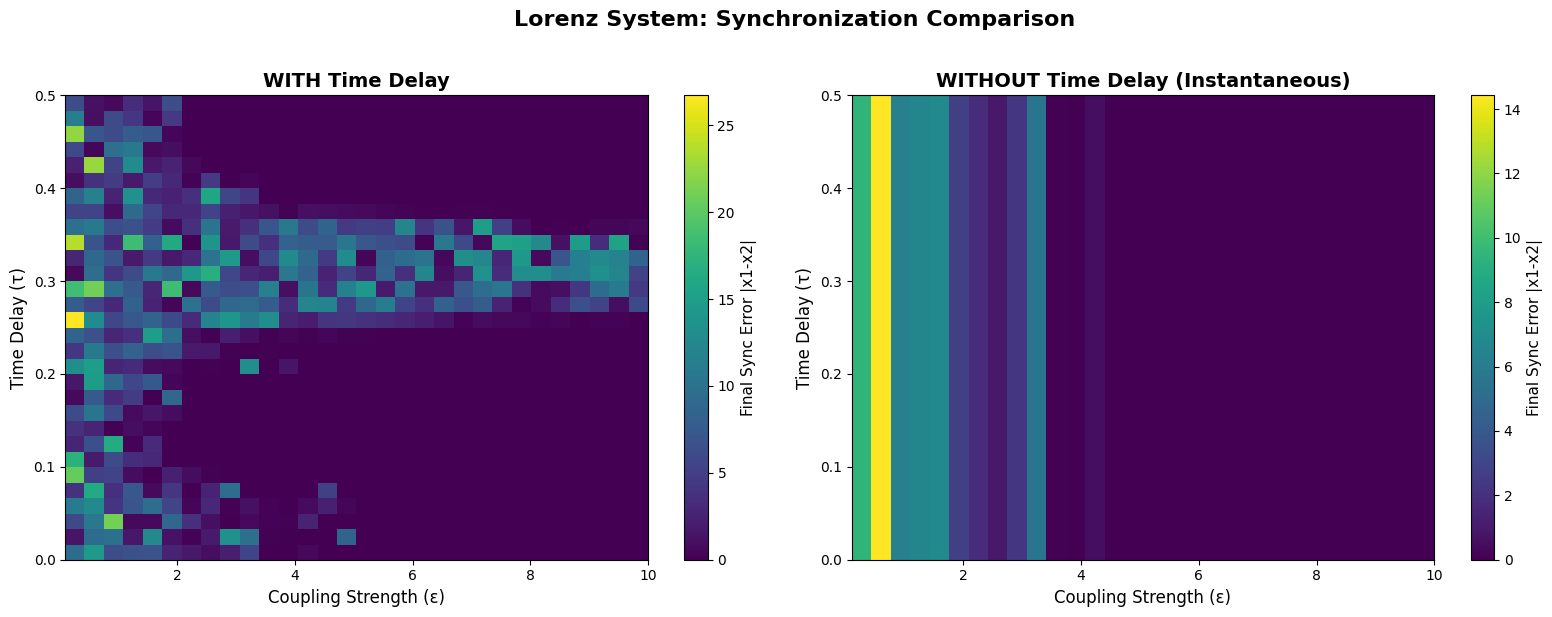


LORENZ SYSTEM - DELAYED vs NON-DELAYED COMPARISON

WITH TIME DELAY:
  Minimum sync error: 0.0000
  Maximum sync error: 26.7222
  Mean sync error: 2.6562
  Std dev: 4.4815

WITHOUT TIME DELAY (Instantaneous):
  Minimum sync error: 0.0000
  Maximum sync error: 14.4255
  Mean sync error: 1.9189
  Std dev: 3.4863



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
s = 10
b = 8/3
r = 28
t0 = 0
tf = 50
N = 20000
h = (tf - t0) / N

# Derivative functions for system 1
def dx1(s, x1_curr, y1_curr, x2_delayed, e):
    return s * (y1_curr - x1_curr) + e * (x2_delayed - x1_curr)

def dy1(r, x1_curr, z1_curr, y1_curr):
    return x1_curr * (r - z1_curr) - y1_curr

def dz1(b, x1_curr, y1_curr, z1_curr):
    return x1_curr * y1_curr - b * z1_curr

# Derivative functions for system 2
def dx2(s, x2_curr, y2_curr, x1_delayed, e):
    return s * (y2_curr - x2_curr) + e * (x1_delayed - x2_curr)

def dy2(r, x2_curr, z2_curr, y2_curr):
    return x2_curr * (r - z2_curr) - y2_curr

def dz2(b, x2_curr, y2_curr, z2_curr):
    return x2_curr * y2_curr - b * z2_curr

# Function to get delayed value
def get_delayed_value(history, time_delaysteps, current_idx):
    idx = current_idx - time_delaysteps
    if idx < 0:
        return history[0]
    else:
        return history[idx]

# RK4 method with time delay
def rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps, e):
    x1_hist = [x10]
    y1_hist = [y10]
    z1_hist = [z10]
    x2_hist = [x20]
    y2_hist = [y20]
    z2_hist = [z20]

    x1_curr = x10
    y1_curr = y10
    z1_curr = z10
    x2_curr = x20
    y2_curr = y20
    z2_curr = z20

    for i in range(N):
        # Get delayed values
        x1_delayed = get_delayed_value(x1_hist, time_delaysteps, i)
        x2_delayed = get_delayed_value(x2_hist, time_delaysteps, i)

        # K1 calculations
        k1x1 = h * dx1(s, x1_curr, y1_curr, x2_delayed, e)
        k1y1 = h * dy1(r, x1_curr, z1_curr, y1_curr)
        k1z1 = h * dz1(b, x1_curr, y1_curr, z1_curr)
        k1x2 = h * dx2(s, x2_curr, y2_curr, x1_delayed, e)
        k1y2 = h * dy2(r, x2_curr, z2_curr, y2_curr)
        k1z2 = h * dz2(b, x2_curr, y2_curr, z2_curr)

        # K2 calculations
        k2x1 = h * dx1(s, x1_curr + k1x1/2, y1_curr + k1y1/2, x2_delayed, e)
        k2y1 = h * dy1(r, x1_curr + k1x1/2, z1_curr + k1z1/2, y1_curr + k1y1/2)
        k2z1 = h * dz1(b, x1_curr + k1x1/2, y1_curr + k1y1/2, z1_curr + k1z1/2)
        k2x2 = h * dx2(s, x2_curr + k1x2/2, y2_curr + k1y2/2, x1_delayed, e)
        k2y2 = h * dy2(r, x2_curr + k1x2/2, z2_curr + k1z2/2, y2_curr + k1y2/2)
        k2z2 = h * dz2(b, x2_curr + k1x2/2, y2_curr + k1y2/2, z2_curr + k1z2/2)

        # K3 calculations
        k3x1 = h * dx1(s, x1_curr + k2x1/2, y1_curr + k2y1/2, x2_delayed, e)
        k3y1 = h * dy1(r, x1_curr + k2x1/2, z1_curr + k2z1/2, y1_curr + k2y1/2)
        k3z1 = h * dz1(b, x1_curr + k2x1/2, y1_curr + k2y1/2, z1_curr + k2z1/2)
        k3x2 = h * dx2(s, x2_curr + k2x2/2, y2_curr + k2y2/2, x1_delayed, e)
        k3y2 = h * dy2(r, x2_curr + k2x2/2, z2_curr + k2z2/2, y2_curr + k2y2/2)
        k3z2 = h * dz2(b, x2_curr + k2x2/2, y2_curr + k2y2/2, z2_curr + k2z2/2)

        # K4 calculations
        k4x1 = h * dx1(s, x1_curr + k3x1, y1_curr + k3y1, x2_delayed, e)
        k4y1 = h * dy1(r, x1_curr + k3x1, z1_curr + k3z1, y1_curr + k3y1)
        k4z1 = h * dz1(b, x1_curr + k3x1, y1_curr + k3y1, z1_curr + k3z1)
        k4x2 = h * dx2(s, x2_curr + k3x2, y2_curr + k3y2, x1_delayed, e)
        k4y2 = h * dy2(r, x2_curr + k3x2, z2_curr + k3z2, y2_curr + k3y2)
        k4z2 = h * dz2(b, x2_curr + k3x2, y2_curr + k3y2, z2_curr + k3z2)

        # Update values
        x1_curr = x1_curr + (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1_curr = y1_curr + (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1_curr = z1_curr + (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6
        x2_curr = x2_curr + (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2_curr = y2_curr + (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2_curr = z2_curr + (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6

        # Store history
        x1_hist.append(x1_curr)
        y1_hist.append(y1_curr)
        z1_hist.append(z1_curr)
        x2_hist.append(x2_curr)
        y2_hist.append(y2_curr)
        z2_hist.append(z2_curr)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist)

# RK4 method without time delay (instantaneous coupling)
def rk4_no_delay(t0, x10, y10, z10, x20, y20, z20, e):
    x1_hist = [x10]
    y1_hist = [y10]
    z1_hist = [z10]
    x2_hist = [x20]
    y2_hist = [y20]
    z2_hist = [z20]

    x1_curr = x10
    y1_curr = y10
    z1_curr = z10
    x2_curr = x20
    y2_curr = y20
    z2_curr = z20

    for i in range(N):
        # No delay - use current values
        x1_instant = x1_curr
        x2_instant = x2_curr

        # K1 calculations
        k1x1 = h * dx1(s, x1_curr, y1_curr, x2_instant, e)
        k1y1 = h * dy1(r, x1_curr, z1_curr, y1_curr)
        k1z1 = h * dz1(b, x1_curr, y1_curr, z1_curr)
        k1x2 = h * dx2(s, x2_curr, y2_curr, x1_instant, e)
        k1y2 = h * dy2(r, x2_curr, z2_curr, y2_curr)
        k1z2 = h * dz2(b, x2_curr, y2_curr, z2_curr)

        # K2 calculations
        k2x1 = h * dx1(s, x1_curr + k1x1/2, y1_curr + k1y1/2, x2_instant, e)
        k2y1 = h * dy1(r, x1_curr + k1x1/2, z1_curr + k1z1/2, y1_curr + k1y1/2)
        k2z1 = h * dz1(b, x1_curr + k1x1/2, y1_curr + k1y1/2, z1_curr + k1z1/2)
        k2x2 = h * dx2(s, x2_curr + k1x2/2, y2_curr + k1y2/2, x1_instant, e)
        k2y2 = h * dy2(r, x2_curr + k1x2/2, z2_curr + k1z2/2, y2_curr + k1y2/2)
        k2z2 = h * dz2(b, x2_curr + k1x2/2, y2_curr + k1y2/2, z2_curr + k1z2/2)

        # K3 calculations
        k3x1 = h * dx1(s, x1_curr + k2x1/2, y1_curr + k2y1/2, x2_instant, e)
        k3y1 = h * dy1(r, x1_curr + k2x1/2, z1_curr + k2z1/2, y1_curr + k2y1/2)
        k3z1 = h * dz1(b, x1_curr + k2x1/2, y1_curr + k2y1/2, z1_curr + k2z1/2)
        k3x2 = h * dx2(s, x2_curr + k2x2/2, y2_curr + k2y2/2, x1_instant, e)
        k3y2 = h * dy2(r, x2_curr + k2x2/2, z2_curr + k2z2/2, y2_curr + k2y2/2)
        k3z2 = h * dz2(b, x2_curr + k2x2/2, y2_curr + k2y2/2, z2_curr + k2z2/2)

        # K4 calculations
        k4x1 = h * dx1(s, x1_curr + k3x1, y1_curr + k3y1, x2_instant, e)
        k4y1 = h * dy1(r, x1_curr + k3x1, z1_curr + k3z1, y1_curr + k3y1)
        k4z1 = h * dz1(b, x1_curr + k3x1, y1_curr + k3y1, z1_curr + k3z1)
        k4x2 = h * dx2(s, x2_curr + k3x2, y2_curr + k3y2, x1_instant, e)
        k4y2 = h * dy2(r, x2_curr + k3x2, z2_curr + k3z2, y2_curr + k3y2)
        k4z2 = h * dz2(b, x2_curr + k3x2, y2_curr + k3y2, z2_curr + k3z2)

        # Update values
        x1_curr = x1_curr + (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1_curr = y1_curr + (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1_curr = z1_curr + (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6
        x2_curr = x2_curr + (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2_curr = y2_curr + (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2_curr = z2_curr + (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6

        # Store history
        x1_hist.append(x1_curr)
        y1_hist.append(y1_curr)
        z1_hist.append(z1_curr)
        x2_hist.append(x2_curr)
        y2_hist.append(y2_curr)
        z2_hist.append(z2_curr)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist)

# Initial conditions
x10, y10, z10 = 20, 20, 20
x20, y20, z20 = 10, 10, 10

# Parameter ranges
coupling_values = np.linspace(0.1, 10, 30)  # Coupling strength
delay_values = np.linspace(0.0, 0.5, 30)    # Time delay

# Initialize synchronization error matrices
sync_error_delay_map = np.zeros((len(delay_values), len(coupling_values)))
sync_error_no_delay_map = np.zeros((len(delay_values), len(coupling_values)))

print("Computing parameter space maps for Lorenz system...")
print(f"Coupling range: {coupling_values[0]:.2f} to {coupling_values[-1]:.2f}")
print(f"Delay range: {delay_values[0]:.3f} to {delay_values[-1]:.3f}")
print(f"Total simulations: {2 * len(coupling_values) * len(delay_values)}")

# Compute synchronization error for each parameter combination
total_sims = len(coupling_values) * len(delay_values)
sim_count = 0

for i, tau in enumerate(delay_values):
    for j, e in enumerate(coupling_values):
        sim_count += 1
        if sim_count % 100 == 0:
            print(f"Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%)")

        time_delaysteps = int(tau / h)

        # Run simulation WITH delay
        x1_d, y1_d, z1_d, x2_d, y2_d, z2_d = rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps, e)
        sync_error_delay_map[i, j] = np.abs(x1_d[-1] - x2_d[-1])

        # Run simulation WITHOUT delay
        x1_n, y1_n, z1_n, x2_n, y2_n, z2_n = rk4_no_delay(t0, x10, y10, z10, x20, y20, z20, e)
        sync_error_no_delay_map[i, j] = np.abs(x1_n[-1] - x2_n[-1])

print("Simulation complete!")

# Visualization - Side by side comparison
fig = plt.figure(figsize=(16, 6))

# 1. With Time Delay
ax1 = plt.subplot(1, 2, 1)
im1 = ax1.imshow(sync_error_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax1.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax1.set_ylabel('Time Delay (τ)', fontsize=12)
ax1.set_title('WITH Time Delay', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Final Sync Error |x1-x2|', fontsize=11)

# 2. Without Time Delay (instantaneous)
ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(sync_error_no_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax2.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax2.set_ylabel('Time Delay (τ)', fontsize=12)
ax2.set_title('WITHOUT Time Delay (Instantaneous)', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Final Sync Error |x1-x2|', fontsize=11)

plt.suptitle('Lorenz System: Synchronization Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [ ]:
#2 coupled rossler system

Running Rossler simulation with time delay...
Running Rossler simulation without time delay...


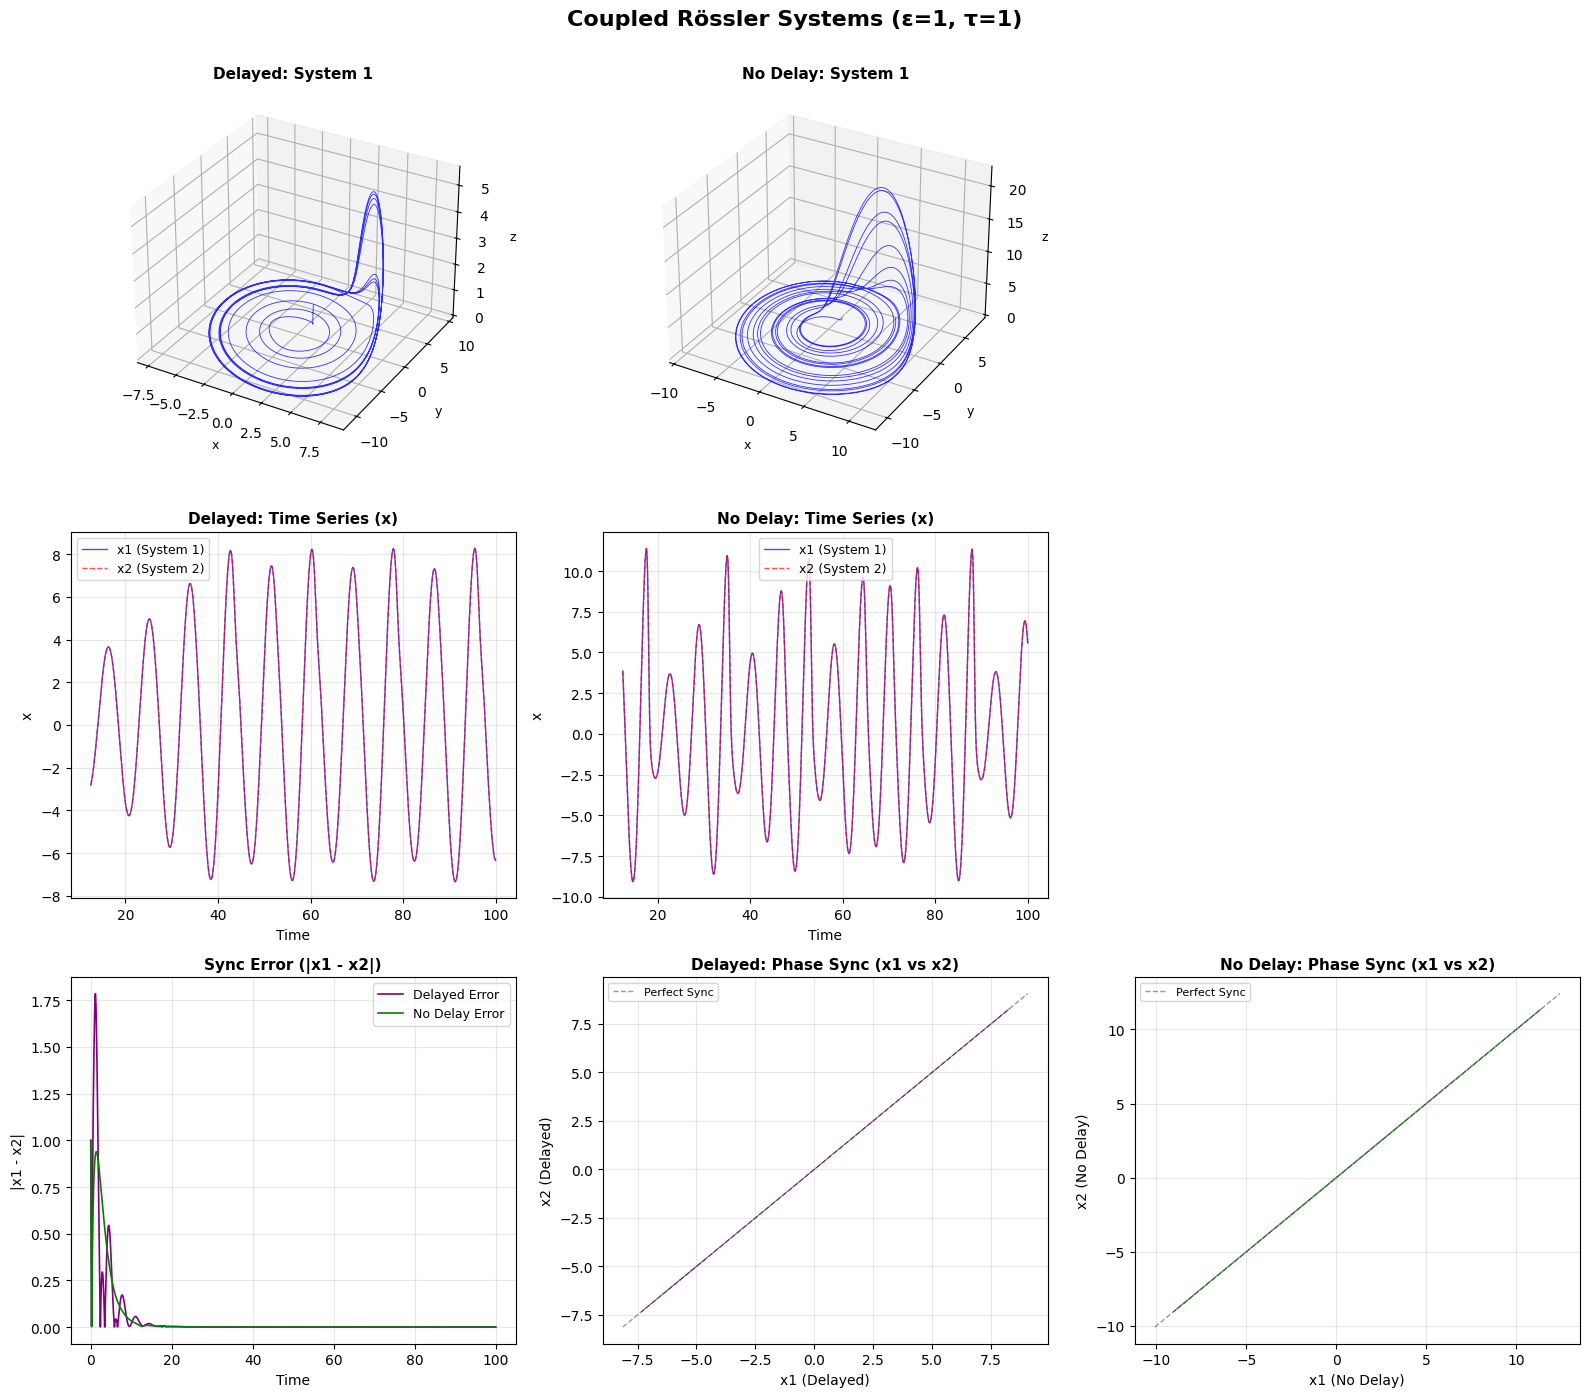


RÖSSLER SIMULATION RESULTS
Coupling Strength (ε): 1
Time Delay (τ): 1
Simulation Time: 0 to 100
Number of Steps: 40000

Final Synchronization Error:
  With Delay:    0.000000
  Without Delay: 0.000000

Mean Synchronization Error:
  With Delay:    0.038398
  Without Delay: 0.037571


In [ ]:
#coupled rossler system
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Parameters for Rossler System
# ==========================================
# Standard Rossler parameters: a=0.2, b=0.2, c=5.7
a = 0.2
b = 0.2
c = 5.7

# Coupling and Time parameters
e = 1        # Coupling strength
t0 = 0
tf = 100        # Increased time for Rossler as it oscillates slower than Lorenz
N = 40000       # Steps
h = (tf - t0) / N
tau = 1   # Time delay
time_delaysteps = int(tau / h)

# ==========================================
# 2. Derivative Functions (Rossler)
# ==========================================

# System 1 derivatives
def dx1(y1_curr, z1_curr, x1_curr, x2_delayed, e):
    # Rossler dx = -y - z. Added coupling term: + e * (x2_delayed - x1)
    return (-y1_curr - z1_curr) + e * (x2_delayed - x1_curr)

def dy1(x1_curr, y1_curr, a):
    # Rossler dy = x + ay
    return x1_curr + a * y1_curr

def dz1(x1_curr, z1_curr, b, c):
    # Rossler dz = b + z(x - c)
    return b + z1_curr * (x1_curr - c)

# System 2 derivatives
def dx2(y2_curr, z2_curr, x2_curr, x1_delayed, e):
    # Rossler dx = -y - z. Added coupling term: + e * (x1_delayed - x2)
    return (-y2_curr - z2_curr) + e * (x1_delayed - x2_curr)

def dy2(x2_curr, y2_curr, a):
    return x2_curr + a * y2_curr

def dz2(x2_curr, z2_curr, b, c):
    return b + z2_curr * (x2_curr - c)

# ==========================================
# 3. Helper Functions
# ==========================================

def get_delayed_value(history, time_delaysteps, current_idx):
    idx = current_idx - time_delaysteps
    if idx < 0:
        return history[0]
    else:
        return history[idx]

# ==========================================
# 4. RK4 Solvers
# ==========================================

# RK4 method with time delay
def rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps):
    x1_hist, y1_hist, z1_hist = [x10], [y10], [z10]
    x2_hist, y2_hist, z2_hist = [x20], [y20], [z20]
    t_hist = [t0]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20
    t = t0

    for i in range(N):
        # Retrieve delayed x values
        x1_del = get_delayed_value(x1_hist, time_delaysteps, i)
        x2_del = get_delayed_value(x2_hist, time_delaysteps, i)

        # --- K1 ---
        k1x1 = h * dx1(y1, z1, x1, x2_del, e)
        k1y1 = h * dy1(x1, y1, a)
        k1z1 = h * dz1(x1, z1, b, c)

        k1x2 = h * dx2(y2, z2, x2, x1_del, e)
        k1y2 = h * dy2(x2, y2, a)
        k1z2 = h * dz2(x2, z2, b, c)

        # --- K2 ---
        k2x1 = h * dx1(y1 + k1y1/2, z1 + k1z1/2, x1 + k1x1/2, x2_del, e)
        k2y1 = h * dy1(x1 + k1x1/2, y1 + k1y1/2, a)
        k2z1 = h * dz1(x1 + k1x1/2, z1 + k1z1/2, b, c)

        k2x2 = h * dx2(y2 + k1y2/2, z2 + k1z2/2, x2 + k1x2/2, x1_del, e)
        k2y2 = h * dy2(x2 + k1x2/2, y2 + k1y2/2, a)
        k2z2 = h * dz2(x2 + k1x2/2, z2 + k1z2/2, b, c)

        # --- K3 ---
        k3x1 = h * dx1(y1 + k2y1/2, z1 + k2z1/2, x1 + k2x1/2, x2_del, e)
        k3y1 = h * dy1(x1 + k2x1/2, y1 + k2y1/2, a)
        k3z1 = h * dz1(x1 + k2x1/2, z1 + k2z1/2, b, c)

        k3x2 = h * dx2(y2 + k2y2/2, z2 + k2z2/2, x2 + k2x2/2, x1_del, e)
        k3y2 = h * dy2(x2 + k2x2/2, y2 + k2y2/2, a)
        k3z2 = h * dz2(x2 + k2x2/2, z2 + k2z2/2, b, c)

        # --- K4 ---
        k4x1 = h * dx1(y1 + k3y1, z1 + k3z1, x1 + k3x1, x2_del, e)
        k4y1 = h * dy1(x1 + k3x1, y1 + k3y1, a)
        k4z1 = h * dz1(x1 + k3x1, z1 + k3z1, b, c)

        k4x2 = h * dx2(y2 + k3y2, z2 + k3z2, x2 + k3x2, x1_del, e)
        k4y2 = h * dy2(x2 + k3x2, y2 + k3y2, a)
        k4z2 = h * dz2(x2 + k3x2, z2 + k3z2, b, c)

        # Update
        x1 += (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1 += (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1 += (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6

        x2 += (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2 += (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2 += (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6
        t += h

        x1_hist.append(x1); y1_hist.append(y1); z1_hist.append(z1)
        x2_hist.append(x2); y2_hist.append(y2); z2_hist.append(z2)
        t_hist.append(t)

    return map(np.array, [x1_hist, y1_hist, z1_hist, x2_hist, y2_hist, z2_hist, t_hist])

# RK4 method without time delay (instantaneous)
def rk4_no_delay(t0, x10, y10, z10, x20, y20, z20):
    x1_hist, y1_hist, z1_hist = [x10], [y10], [z10]
    x2_hist, y2_hist, z2_hist = [x20], [y20], [z20]
    t_hist = [t0]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20
    t = t0

    for i in range(N):
        # Instantaneous coupling: use current values
        x1_inst = x1
        x2_inst = x2

        # --- K1 ---
        k1x1 = h * dx1(y1, z1, x1, x2_inst, e)
        k1y1 = h * dy1(x1, y1, a)
        k1z1 = h * dz1(x1, z1, b, c)

        k1x2 = h * dx2(y2, z2, x2, x1_inst, e)
        k1y2 = h * dy2(x2, y2, a)
        k1z2 = h * dz2(x2, z2, b, c)

        # --- K2 ---
        k2x1 = h * dx1(y1 + k1y1/2, z1 + k1z1/2, x1 + k1x1/2, x2_inst, e)
        k2y1 = h * dy1(x1 + k1x1/2, y1 + k1y1/2, a)
        k2z1 = h * dz1(x1 + k1x1/2, z1 + k1z1/2, b, c)

        k2x2 = h * dx2(y2 + k1y2/2, z2 + k1z2/2, x2 + k1x2/2, x1_inst, e)
        k2y2 = h * dy2(x2 + k1x2/2, y2 + k1y2/2, a)
        k2z2 = h * dz2(x2 + k1x2/2, z2 + k1z2/2, b, c)

        # --- K3 ---
        k3x1 = h * dx1(y1 + k2y1/2, z1 + k2z1/2, x1 + k2x1/2, x2_inst, e)
        k3y1 = h * dy1(x1 + k2x1/2, y1 + k2y1/2, a)
        k3z1 = h * dz1(x1 + k2x1/2, z1 + k2z1/2, b, c)

        k3x2 = h * dx2(y2 + k2y2/2, z2 + k2z2/2, x2 + k2x2/2, x1_inst, e)
        k3y2 = h * dy2(x2 + k2x2/2, y2 + k2y2/2, a)
        k3z2 = h * dz2(x2 + k2x2/2, z2 + k2z2/2, b, c)

        # --- K4 ---
        k4x1 = h * dx1(y1 + k3y1, z1 + k3z1, x1 + k3x1, x2_inst, e)
        k4y1 = h * dy1(x1 + k3x1, y1 + k3y1, a)
        k4z1 = h * dz1(x1 + k3x1, z1 + k3z1, b, c)

        k4x2 = h * dx2(y2 + k3y2, z2 + k3z2, x2 + k3x2, x1_inst, e)
        k4y2 = h * dy2(x2 + k3x2, y2 + k3y2, a)
        k4z2 = h * dz2(x2 + k3x2, z2 + k3z2, b, c)

        # Update
        x1 += (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1 += (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1 += (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6

        x2 += (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2 += (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2 += (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6
        t += h

        x1_hist.append(x1); y1_hist.append(y1); z1_hist.append(z1)
        x2_hist.append(x2); y2_hist.append(y2); z2_hist.append(z2)
        t_hist.append(t)

    return map(np.array, [x1_hist, y1_hist, z1_hist, x2_hist, y2_hist, z2_hist, t_hist])

# ==========================================
# 5. Execution & Plotting
# ==========================================

# Initial conditions
x10, y10, z10 = 1.0, 1.0, 1.0
x20, y20, z20 = 2.0, 3.0, 3.0

print("Running Rossler simulation with time delay...")
x1_d, y1_d, z1_d, x2_d, y2_d, z2_d, t_d = rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps)

print("Running Rossler simulation without time delay...")
x1_n, y1_n, z1_n, x2_n, y2_n, z2_n, t_n = rk4_no_delay(t0, x10, y10, z10, x20, y20, z20)

# Calculate errors
sync_error_delay = np.abs(x1_d - x2_d)
sync_error_no = np.abs(x1_n - x2_n)

# Create figure with layout: 2 top, 2 middle, 3 bottom
fig = plt.figure(figsize=(16, 14))

# ==========================================
# TOP ROW: 3D Phase Space (2 plots - separate systems)
# ==========================================
# Delayed 3D Phase Space - System 1
ax1 = fig.add_subplot(3, 3, 1, projection='3d')
ax1.plot(x1_d, y1_d, z1_d, 'b', lw=0.6, alpha=0.8)
ax1.set_xlabel('x', fontsize=9)
ax1.set_ylabel('y', fontsize=9)
ax1.set_zlabel('z', fontsize=9)
ax1.set_title('Delayed: System 1', fontsize=11, fontweight='bold')

# No Delay 3D Phase Space - System 1
ax2 = fig.add_subplot(3, 3, 2, projection='3d')
ax2.plot(x1_n, y1_n, z1_n, 'b', lw=0.6, alpha=0.8)
ax2.set_xlabel('x', fontsize=9)
ax2.set_ylabel('y', fontsize=9)
ax2.set_zlabel('z', fontsize=9)
ax2.set_title('No Delay: System 1', fontsize=11, fontweight='bold')

# ==========================================
# MIDDLE ROW: Time Series (2 plots)
# ==========================================
# Delayed Time Series
ax3 = fig.add_subplot(3, 3, 4)
start_time = 5000
ax3.plot(t_d[start_time:], x1_d[start_time:], 'b', lw=1, alpha=0.7, label='x1 (System 1)')
ax3.plot(t_d[start_time:], x2_d[start_time:], 'r--', lw=1, alpha=0.7, label='x2 (System 2)')
ax3.set_xlabel('Time', fontsize=10)
ax3.set_ylabel('x', fontsize=10)
ax3.set_title('Delayed: Time Series (x)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# No Delay Time Series
ax4 = fig.add_subplot(3, 3, 5)
ax4.plot(t_n[start_time:], x1_n[start_time:], 'b', lw=1, alpha=0.7, label='x1 (System 1)')
ax4.plot(t_n[start_time:], x2_n[start_time:], 'r--', lw=1, alpha=0.7, label='x2 (System 2)')
ax4.set_xlabel('Time', fontsize=10)
ax4.set_ylabel('x', fontsize=10)
ax4.set_title('No Delay: Time Series (x)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ==========================================
# BOTTOM ROW: 3 plots (Error + Phase Sync)
# ==========================================
# Synchronization Error Comparison
ax5 = fig.add_subplot(3, 3, 7)
ax5.plot(t_d, sync_error_delay, 'purple', lw=1.2, label='Delayed Error')
ax5.plot(t_n, sync_error_no, 'green', lw=1.2, label='No Delay Error')
ax5.set_xlabel('Time', fontsize=10)
ax5.set_ylabel('|x1 - x2|', fontsize=10)
ax5.set_title('Sync Error (|x1 - x2|)', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Delayed Phase Synchronization - x1 vs x2
ax6 = fig.add_subplot(3, 3, 8)
start_idx = 36000
ax6.plot(x1_d[start_idx:], x2_d[start_idx:], 'purple', lw=0.6, alpha=0.6)
ax6.set_xlabel('x1 (Delayed)', fontsize=10)
ax6.set_ylabel('x2 (Delayed)', fontsize=10)
ax6.set_title('Delayed: Phase Sync (x1 vs x2)', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)
# Add diagonal line for perfect sync
lims = [min(ax6.get_xlim()[0], ax6.get_ylim()[0]),
        max(ax6.get_xlim()[1], ax6.get_ylim()[1])]
ax6.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='Perfect Sync')
ax6.legend(fontsize=8)

# No Delay Phase Synchronization - x1 vs x2
ax7 = fig.add_subplot(3, 3, 9)
ax7.plot(x1_n[start_time:], x2_n[start_time:], 'green', lw=0.6, alpha=0.6)
ax7.set_xlabel('x1 (No Delay)', fontsize=10)
ax7.set_ylabel('x2 (No Delay)', fontsize=10)
ax7.set_title('No Delay: Phase Sync (x1 vs x2)', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3)
# Add diagonal line for perfect sync
lims = [min(ax7.get_xlim()[0], ax7.get_ylim()[0]),
        max(ax7.get_xlim()[1], ax7.get_ylim()[1])]
ax7.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='Perfect Sync')
ax7.legend(fontsize=8)

plt.suptitle(f'Coupled Rössler Systems (ε={e}, τ={tau})',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# ==========================================
# Statistics
# ==========================================
print("\n" + "="*60)
print("RÖSSLER SIMULATION RESULTS")
print("="*60)
print(f"Coupling Strength (ε): {e}")
print(f"Time Delay (τ): {tau}")
print(f"Simulation Time: {t0} to {tf}")
print(f"Number of Steps: {N}")
print(f"\nFinal Synchronization Error:")
print(f"  With Delay:    {sync_error_delay[-1]:.6f}")
print(f"  Without Delay: {sync_error_no[-1]:.6f}")
print(f"\nMean Synchronization Error:")
print(f"  With Delay:    {np.mean(sync_error_delay):.6f}")
print(f"  Without Delay: {np.mean(sync_error_no):.6f}")
print("="*60)

Computing parameter space maps for Rossler system...
Coupling range: 0.10 to 2.00
Delay range: 0.000 to 5.000
Total simulations: 1800
Progress: 100/900 (11.1%)
Progress: 200/900 (22.2%)
Progress: 300/900 (33.3%)
Progress: 400/900 (44.4%)
Progress: 500/900 (55.6%)
Progress: 600/900 (66.7%)
Progress: 700/900 (77.8%)
Progress: 800/900 (88.9%)
Progress: 900/900 (100.0%)
Simulation complete!


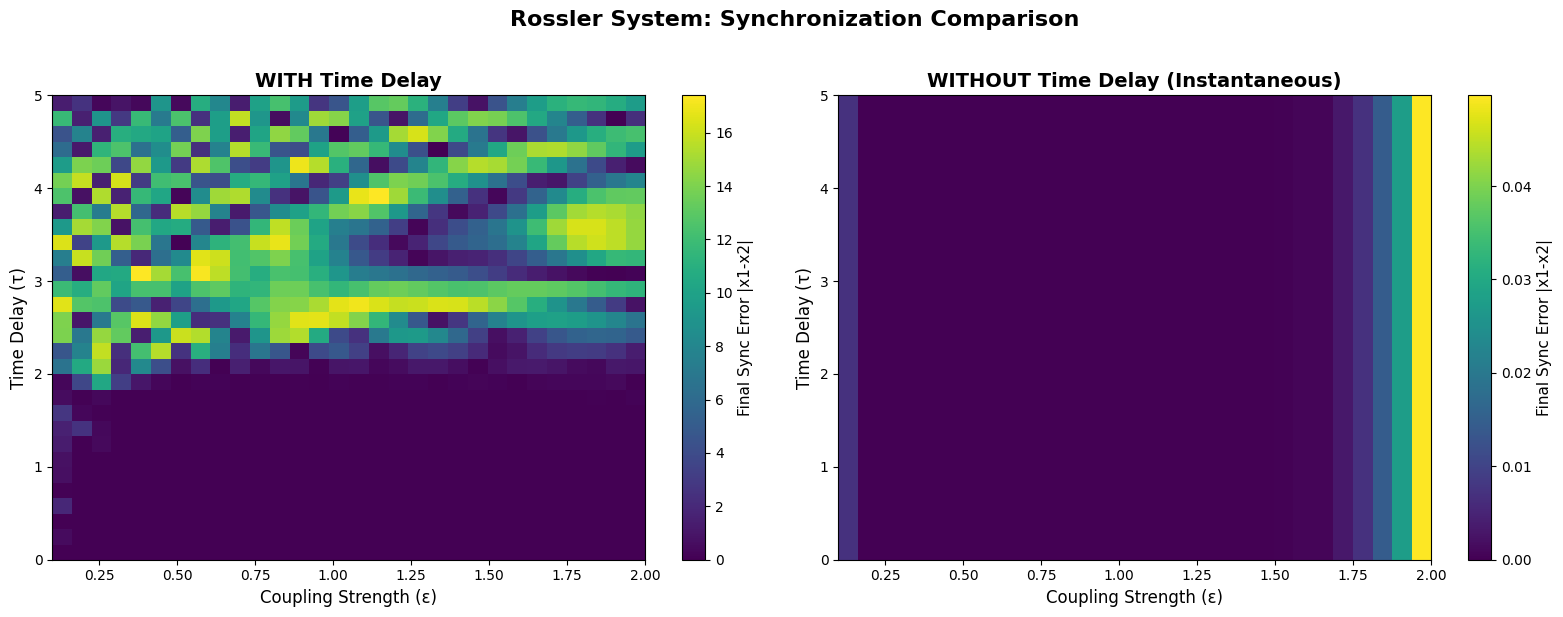


ROSSLER SYSTEM - DELAYED vs NON-DELAYED COMPARISON

WITH TIME DELAY:
  Minimum sync error: 0.0000
  Maximum sync error: 17.3972
  Mean sync error: 5.0233

WITHOUT TIME DELAY (Instantaneous):
  Minimum sync error: 0.0000
  Maximum sync error: 0.0497
  Mean sync error: 0.0037



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters for Rossler System
# ==========================================
a = 0.2
b = 0.2
c = 5.7

t0 = 0
tf = 100
N = 40000
h = (tf - t0) / N

# ==========================================
# Derivative Functions (Rossler)
# ==========================================

# System 1 derivatives
def dx1(y1_curr, z1_curr, x1_curr, x2_delayed, e):
    return (-y1_curr - z1_curr) + e * (x2_delayed - x1_curr)

def dy1(x1_curr, y1_curr, a):
    return x1_curr + a * y1_curr

def dz1(x1_curr, z1_curr, b, c):
    return b + z1_curr * (x1_curr - c)

# System 2 derivatives
def dx2(y2_curr, z2_curr, x2_curr, x1_delayed, e):
    return (-y2_curr - z2_curr) + e * (x1_delayed - x2_curr)

def dy2(x2_curr, y2_curr, a):
    return x2_curr + a * y2_curr

def dz2(x2_curr, z2_curr, b, c):
    return b + z2_curr * (x2_curr - c)

# ==========================================
# Helper Functions
# ==========================================

def get_delayed_value(history, time_delaysteps, current_idx):
    idx = current_idx - time_delaysteps
    if idx < 0:
        return history[0]
    else:
        return history[idx]

# ==========================================
# RK4 Solvers
# ==========================================

# RK4 method with time delay
def rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps, e):
    x1_hist, y1_hist, z1_hist = [x10], [y10], [z10]
    x2_hist, y2_hist, z2_hist = [x20], [y20], [z20]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20

    for i in range(N):
        # Retrieve delayed x values
        x1_del = get_delayed_value(x1_hist, time_delaysteps, i)
        x2_del = get_delayed_value(x2_hist, time_delaysteps, i)

        # --- K1 ---
        k1x1 = h * dx1(y1, z1, x1, x2_del, e)
        k1y1 = h * dy1(x1, y1, a)
        k1z1 = h * dz1(x1, z1, b, c)

        k1x2 = h * dx2(y2, z2, x2, x1_del, e)
        k1y2 = h * dy2(x2, y2, a)
        k1z2 = h * dz2(x2, z2, b, c)

        # --- K2 ---
        k2x1 = h * dx1(y1 + k1y1/2, z1 + k1z1/2, x1 + k1x1/2, x2_del, e)
        k2y1 = h * dy1(x1 + k1x1/2, y1 + k1y1/2, a)
        k2z1 = h * dz1(x1 + k1x1/2, z1 + k1z1/2, b, c)

        k2x2 = h * dx2(y2 + k1y2/2, z2 + k1z2/2, x2 + k1x2/2, x1_del, e)
        k2y2 = h * dy2(x2 + k1x2/2, y2 + k1y2/2, a)
        k2z2 = h * dz2(x2 + k1x2/2, z2 + k1z2/2, b, c)

        # --- K3 ---
        k3x1 = h * dx1(y1 + k2y1/2, z1 + k2z1/2, x1 + k2x1/2, x2_del, e)
        k3y1 = h * dy1(x1 + k2x1/2, y1 + k2y1/2, a)
        k3z1 = h * dz1(x1 + k2x1/2, z1 + k2z1/2, b, c)

        k3x2 = h * dx2(y2 + k2y2/2, z2 + k2z2/2, x2 + k2x2/2, x1_del, e)
        k3y2 = h * dy2(x2 + k2x2/2, y2 + k2y2/2, a)
        k3z2 = h * dz2(x2 + k2x2/2, z2 + k2z2/2, b, c)

        # --- K4 ---
        k4x1 = h * dx1(y1 + k3y1, z1 + k3z1, x1 + k3x1, x2_del, e)
        k4y1 = h * dy1(x1 + k3x1, y1 + k3y1, a)
        k4z1 = h * dz1(x1 + k3x1, z1 + k3z1, b, c)

        k4x2 = h * dx2(y2 + k3y2, z2 + k3z2, x2 + k3x2, x1_del, e)
        k4y2 = h * dy2(x2 + k3x2, y2 + k3y2, a)
        k4z2 = h * dz2(x2 + k3x2, z2 + k3z2, b, c)

        # Update
        x1 += (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1 += (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1 += (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6

        x2 += (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2 += (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2 += (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6

        x1_hist.append(x1); y1_hist.append(y1); z1_hist.append(z1)
        x2_hist.append(x2); y2_hist.append(y2); z2_hist.append(z2)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist)

# RK4 method without time delay (instantaneous)
def rk4_no_delay(t0, x10, y10, z10, x20, y20, z20, e):
    x1_hist, y1_hist, z1_hist = [x10], [y10], [z10]
    x2_hist, y2_hist, z2_hist = [x20], [y20], [z20]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20

    for i in range(N):
        # Instantaneous coupling: use current values
        x1_inst = x1
        x2_inst = x2

        # --- K1 ---
        k1x1 = h * dx1(y1, z1, x1, x2_inst, e)
        k1y1 = h * dy1(x1, y1, a)
        k1z1 = h * dz1(x1, z1, b, c)

        k1x2 = h * dx2(y2, z2, x2, x1_inst, e)
        k1y2 = h * dy2(x2, y2, a)
        k1z2 = h * dz2(x2, z2, b, c)

        # --- K2 ---
        k2x1 = h * dx1(y1 + k1y1/2, z1 + k1z1/2, x1 + k1x1/2, x2_inst, e)
        k2y1 = h * dy1(x1 + k1x1/2, y1 + k1y1/2, a)
        k2z1 = h * dz1(x1 + k1x1/2, z1 + k1z1/2, b, c)

        k2x2 = h * dx2(y2 + k1y2/2, z2 + k1z2/2, x2 + k1x2/2, x1_inst, e)
        k2y2 = h * dy2(x2 + k1x2/2, y2 + k1y2/2, a)
        k2z2 = h * dz2(x2 + k1x2/2, z2 + k1z2/2, b, c)

        # --- K3 ---
        k3x1 = h * dx1(y1 + k2y1/2, z1 + k2z1/2, x1 + k2x1/2, x2_inst, e)
        k3y1 = h * dy1(x1 + k2x1/2, y1 + k2y1/2, a)
        k3z1 = h * dz1(x1 + k2x1/2, z1 + k2z1/2, b, c)

        k3x2 = h * dx2(y2 + k2y2/2, z2 + k2z2/2, x2 + k2x2/2, x1_inst, e)
        k3y2 = h * dy2(x2 + k2x2/2, y2 + k2y2/2, a)
        k3z2 = h * dz2(x2 + k2x2/2, z2 + k2z2/2, b, c)

        # --- K4 ---
        k4x1 = h * dx1(y1 + k3y1, z1 + k3z1, x1 + k3x1, x2_inst, e)
        k4y1 = h * dy1(x1 + k3x1, y1 + k3y1, a)
        k4z1 = h * dz1(x1 + k3x1, z1 + k3z1, b, c)

        k4x2 = h * dx2(y2 + k3y2, z2 + k3z2, x2 + k3x2, x1_inst, e)
        k4y2 = h * dy2(x2 + k3x2, y2 + k3y2, a)
        k4z2 = h * dz2(x2 + k3x2, z2 + k3z2, b, c)

        # Update
        x1 += (k1x1 + 2*k2x1 + 2*k3x1 + k4x1) / 6
        y1 += (k1y1 + 2*k2y1 + 2*k3y1 + k4y1) / 6
        z1 += (k1z1 + 2*k2z1 + 2*k3z1 + k4z1) / 6

        x2 += (k1x2 + 2*k2x2 + 2*k3x2 + k4x2) / 6
        y2 += (k1y2 + 2*k2y2 + 2*k3y2 + k4y2) / 6
        z2 += (k1z2 + 2*k2z2 + 2*k3z2 + k4z2) / 6

        x1_hist.append(x1); y1_hist.append(y1); z1_hist.append(z1)
        x2_hist.append(x2); y2_hist.append(y2); z2_hist.append(z2)

    return np.array(x1_hist), np.array(y1_hist), np.array(z1_hist), \
           np.array(x2_hist), np.array(y2_hist), np.array(z2_hist)

# ==========================================
# Initial Conditions
# ==========================================
x10, y10, z10 = 1.0, 1.0, 1.0
x20, y20, z20 = 2.0, 3.0, 3.0

# ==========================================
# Parameter Ranges
# ==========================================
coupling_values = np.linspace(0.1, 2.0, 30)  # Coupling strength
delay_values = np.linspace(0.0, 5.0, 30)     # Time delay

# Initialize synchronization error matrices
sync_error_delay_map = np.zeros((len(delay_values), len(coupling_values)))
sync_error_no_delay_map = np.zeros((len(delay_values), len(coupling_values)))

print("Computing parameter space maps for Rossler system...")
print(f"Coupling range: {coupling_values[0]:.2f} to {coupling_values[-1]:.2f}")
print(f"Delay range: {delay_values[0]:.3f} to {delay_values[-1]:.3f}")
print(f"Total simulations: {2 * len(coupling_values) * len(delay_values)}")

# ==========================================
# Compute Synchronization Error Map
# ==========================================
total_sims = len(coupling_values) * len(delay_values)
sim_count = 0

for i, tau in enumerate(delay_values):
    for j, e in enumerate(coupling_values):
        sim_count += 1
        if sim_count % 100 == 0:
            print(f"Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%)")

        time_delaysteps = int(tau / h)

        # Run simulation WITH delay
        x1_d, y1_d, z1_d, x2_d, y2_d, z2_d = rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps, e)
        sync_error_delay_map[i, j] = np.abs(x1_d[-1] - x2_d[-1])

        # Run simulation WITHOUT delay
        x1_n, y1_n, z1_n, x2_n, y2_n, z2_n = rk4_no_delay(t0, x10, y10, z10, x20, y20, z20, e)
        sync_error_no_delay_map[i, j] = np.abs(x1_n[-1] - x2_n[-1])

print("Simulation complete!")

# ==========================================
# Visualization - Side by side comparison
# ==========================================
fig = plt.figure(figsize=(16, 6))

# 1. With Time Delay
ax1 = plt.subplot(1, 2, 1)
im1 = ax1.imshow(sync_error_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax1.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax1.set_ylabel('Time Delay (τ)', fontsize=12)
ax1.set_title('WITH Time Delay', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Final Sync Error |x1-x2|', fontsize=11)

# 2. Without Time Delay (instantaneous)
ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(sync_error_no_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax2.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax2.set_ylabel('Time Delay (τ)', fontsize=12)
ax2.set_title('WITHOUT Time Delay (Instantaneous)', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Final Sync Error |x1-x2|', fontsize=11)

plt.suptitle('Rossler System: Synchronization Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



Running simulations...


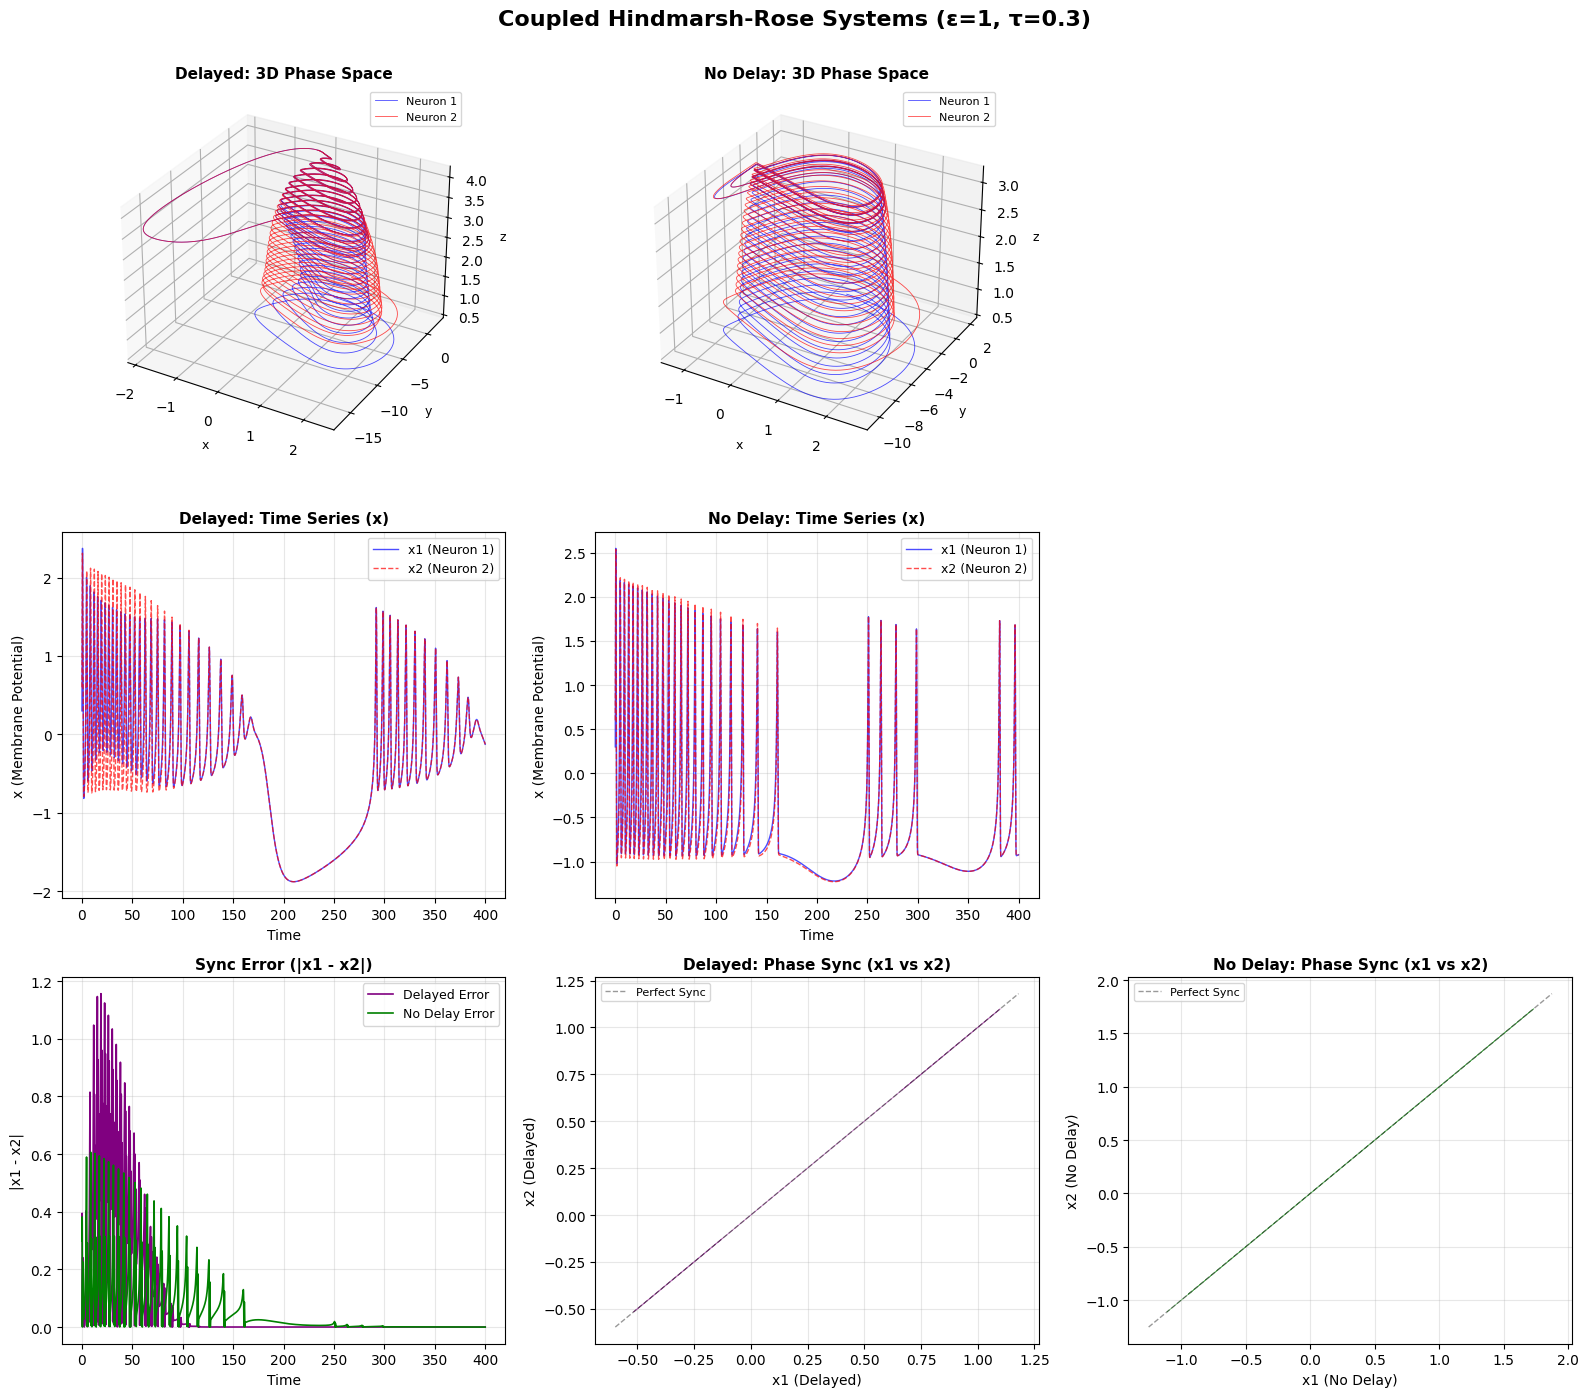


HINDMARSH-ROSE SIMULATION RESULTS
Coupling Strength (ε): 1
Time Delay (τ): 0.3
Simulation Time: 0 to 400
Number of Steps: 40000

Final Synchronization Error:
  With Delay:    0.000000
  Without Delay: 0.000032

Mean Synchronization Error:
  With Delay:    0.082058
  Without Delay: 0.057256


In [ ]:
# 2 coupled Hind Marsh  models
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Parameters for Hindmarsh-Rose System
# ==========================================
r_param = 0.005
I_param = 3.1
a_param = 1.0
b_param = 3.0
c_param = 1.0
d_param = 5.0
s_param = 4.0
x_rest = -1.6

# Coupling and Time parameters
e = 1   # Coupling strength
t0 = 0
tf = 400
N = 40000
h = (tf - t0) / N
tau = 0.3 # Time delay
time_delaysteps = int(tau / h)

# ==========================================
# 2. Derivative Functions
# ==========================================

def dx_dt(x, y, z, x_delayed, e_val):
    return y + (b_param * x**2) - (a_param * x**3) - z + I_param + e_val * (x_delayed - x)

def dy_dt(x, y):
    return c_param - (d_param * x**2) - y

def dz_dt(x, z):
    return r_param * (s_param * (x - x_rest) - z)

# ==========================================
# 3. Helper Functions
# ==========================================

def get_delayed_value(history, delay_steps, current_idx):
    idx = current_idx - delay_steps
    return history[idx] if idx >= 0 else history[0]

# ==========================================
# 4. RK4 Solver
# ==========================================

def simulate_hr(with_delay=True, x10=0.3, y10=1.0, z10=0.5, x20=0.6, y20=2.0, z20=1.0):
    x1_h, y1_h, z1_h = [x10], [y10], [z10]
    x2_h, y2_h, z2_h = [x20], [y20], [z20]
    t_h = [t0]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20
    t = t0

    for i in range(N):
        if with_delay:
            x1_del = get_delayed_value(x1_h, time_delaysteps, i)
            x2_del = get_delayed_value(x2_h, time_delaysteps, i)
        else:
            x1_del, x2_del = x1, x2

        def derivs(cur_x1, cur_y1, cur_z1, cur_x2, cur_y2, cur_z2):
            dot_x1 = dx_dt(cur_x1, cur_y1, cur_z1, x2_del, e)
            dot_y1 = dy_dt(cur_x1, cur_y1)
            dot_z1 = dz_dt(cur_x1, cur_z1)
            dot_x2 = dx_dt(cur_x2, cur_y2, cur_z2, x1_del, e)
            dot_y2 = dy_dt(cur_x2, cur_y2)
            dot_z2 = dz_dt(cur_x2, cur_z2)
            return np.array([dot_x1, dot_y1, dot_z1, dot_x2, dot_y2, dot_z2])

        k1 = h * derivs(x1, y1, z1, x2, y2, z2)
        k2 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k1/2))
        k3 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k2/2))
        k4 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k3))

        step = (k1 + 2*k2 + 2*k3 + k4) / 6
        x1 += step[0]; y1 += step[1]; z1 += step[2]
        x2 += step[3]; y2 += step[4]; z2 += step[5]
        t += h

        x1_h.append(x1); y1_h.append(y1); z1_h.append(z1)
        x2_h.append(x2); y2_h.append(y2); z2_h.append(z2)
        t_h.append(t)

    return map(np.array, [x1_h, y1_h, z1_h, x2_h, y2_h, z2_h, t_h])

# ==========================================
# 5. Execution & Plotting
# ==========================================

x10, y10, z10 = 0.3, 1.0, 0.5
x20, y20, z20 = 0.6, 2.0, 1.0

# Run simulations
print("Running simulations...")
x1_d, y1_d, z1_d, x2_d, y2_d, z2_d, t_d = simulate_hr(with_delay=True)
x1_n, y1_n, z1_n, x2_n, y2_n, z2_n, t_n = simulate_hr(with_delay=False)

# Errors
err_d = np.abs(x1_d - x2_d)
err_n = np.abs(x1_n - x2_n)

# Create figure with layout: 2 top, 2 middle, 3 bottom
fig = plt.figure(figsize=(16, 14))

# ==========================================
# TOP ROW: 3D Phase Space (2 plots)
# ==========================================
# Delayed 3D Phase Space
ax1 = fig.add_subplot(3, 3, 1, projection='3d')
ax1.plot(x1_d, y1_d, z1_d, 'b', lw=0.6, alpha=0.7, label='Neuron 1')
ax1.plot(x2_d, y2_d, z2_d, 'r', lw=0.6, alpha=0.7, label='Neuron 2')
ax1.set_xlabel('x', fontsize=9)
ax1.set_ylabel('y', fontsize=9)
ax1.set_zlabel('z', fontsize=9)
ax1.set_title('Delayed: 3D Phase Space', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8)

# No Delay 3D Phase Space
ax2 = fig.add_subplot(3, 3, 2, projection='3d')
ax2.plot(x1_n, y1_n, z1_n, 'b', lw=0.6, alpha=0.7, label='Neuron 1')
ax2.plot(x2_n, y2_n, z2_n, 'r', lw=0.6, alpha=0.7, label='Neuron 2')
ax2.set_xlabel('x', fontsize=9)
ax2.set_ylabel('y', fontsize=9)
ax2.set_zlabel('z', fontsize=9)
ax2.set_title('No Delay: 3D Phase Space', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)

# ==========================================
# MIDDLE ROW: Time Series (2 plots)
# ==========================================
# Delayed Time Series
ax3 = fig.add_subplot(3, 3, 4)
ax3.plot(t_d, x1_d, 'b', lw=1, alpha=0.7, label='x1 (Neuron 1)')
ax3.plot(t_d, x2_d, 'r--', lw=1, alpha=0.7, label='x2 (Neuron 2)')
ax3.set_xlabel('Time', fontsize=10)
ax3.set_ylabel('x (Membrane Potential)', fontsize=10)
ax3.set_title('Delayed: Time Series (x)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# No Delay Time Series
ax4 = fig.add_subplot(3, 3, 5)
ax4.plot(t_n, x1_n, 'b', lw=1, alpha=0.7, label='x1 (Neuron 1)')
ax4.plot(t_n, x2_n, 'r--', lw=1, alpha=0.7, label='x2 (Neuron 2)')
ax4.set_xlabel('Time', fontsize=10)
ax4.set_ylabel('x (Membrane Potential)', fontsize=10)
ax4.set_title('No Delay: Time Series (x)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ==========================================
# BOTTOM ROW: 3 plots (Error + Phase Sync)
# ==========================================
# Synchronization Error Comparison
ax5 = fig.add_subplot(3, 3, 7)
ax5.plot(t_d, err_d, 'purple', lw=1.2, label='Delayed Error')
ax5.plot(t_n, err_n, 'green', lw=1.2, label='No Delay Error')
ax5.set_xlabel('Time', fontsize=10)
ax5.set_ylabel('|x1 - x2|', fontsize=10)
ax5.set_title('Sync Error (|x1 - x2|)', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# Delayed Phase Synchronization
ax6 = fig.add_subplot(3, 3, 8)
start_idx = 35000
ax6.plot(x1_d[start_idx:], x2_d[start_idx:], 'purple', lw=0.6, alpha=0.6)
ax6.set_xlabel('x1 (Delayed)', fontsize=10)
ax6.set_ylabel('x2 (Delayed)', fontsize=10)
ax6.set_title('Delayed: Phase Sync (x1 vs x2)', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3)
# Add diagonal line for perfect sync
lims = [min(ax6.get_xlim()[0], ax6.get_ylim()[0]),
        max(ax6.get_xlim()[1], ax6.get_ylim()[1])]
ax6.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='Perfect Sync')
ax6.legend(fontsize=8)

# No Delay Phase Synchronization
ax7 = fig.add_subplot(3, 3, 9)
ax7.plot(x1_n[start_idx:], x2_n[start_idx:], 'green', lw=0.6, alpha=0.6)
ax7.set_xlabel('x1 (No Delay)', fontsize=10)
ax7.set_ylabel('x2 (No Delay)', fontsize=10)
ax7.set_title('No Delay: Phase Sync (x1 vs x2)', fontsize=11, fontweight='bold')
ax7.grid(True, alpha=0.3)
# Add diagonal line for perfect sync
lims = [min(ax7.get_xlim()[0], ax7.get_ylim()[0]),
        max(ax7.get_xlim()[1], ax7.get_ylim()[1])]
ax7.plot(lims, lims, 'k--', alpha=0.4, lw=1, label='Perfect Sync')
ax7.legend(fontsize=8)

plt.suptitle(f'Coupled Hindmarsh-Rose Systems (ε={e}, τ={tau})',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()



Computing parameter space maps for Hindmarsh-Rose system...
Coupling range: 0.10 to 3.00
Delay range: 0.000 to 10.000
Total simulations: 1800
Progress: 100/900 (11.1%)
Progress: 200/900 (22.2%)
Progress: 300/900 (33.3%)
Progress: 400/900 (44.4%)
Progress: 500/900 (55.6%)
Progress: 600/900 (66.7%)
Progress: 700/900 (77.8%)
Progress: 800/900 (88.9%)
Progress: 900/900 (100.0%)
Simulation complete!


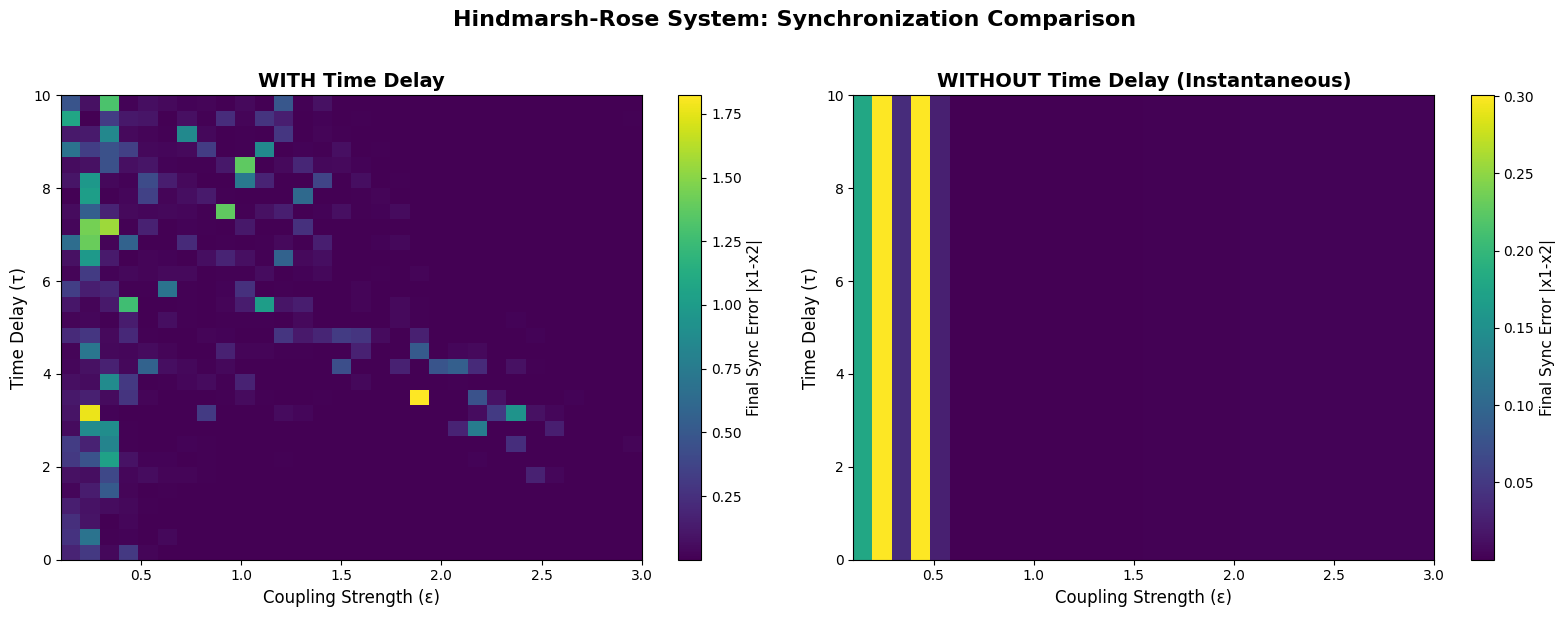


HINDMARSH-ROSE SYSTEM - DELAYED vs NON-DELAYED COMPARISON

WITH TIME DELAY:
  Minimum sync error: 0.0000
  Maximum sync error: 1.8228
  Mean sync error: 0.0716

WITHOUT TIME DELAY (Instantaneous):
  Minimum sync error: 0.0000
  Maximum sync error: 0.3004
  Mean sync error: 0.0296



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters for Hindmarsh-Rose System
# ==========================================
r_param = 0.005
I_param = 3.1
a_param = 1.0
b_param = 3.0
c_param = 1.0
d_param = 5.0
s_param = 4.0
x_rest = -1.6

t0 = 0
tf = 400
N = 40000
h = (tf - t0) / N

# ==========================================
# Derivative Functions
# ==========================================

def dx_dt(x, y, z, x_delayed, e_val):
    return y + (b_param * x**2) - (a_param * x**3) - z + I_param + e_val * (x_delayed - x)

def dy_dt(x, y):
    return c_param - (d_param * x**2) - y

def dz_dt(x, z):
    return r_param * (s_param * (x - x_rest) - z)

# ==========================================
# Helper Functions
# ==========================================

def get_delayed_value(history, delay_steps, current_idx):
    idx = current_idx - delay_steps
    return history[idx] if idx >= 0 else history[0]

# ==========================================
# RK4 Solver with Time Delay
# ==========================================

def rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps, e):
    x1_h, y1_h, z1_h = [x10], [y10], [z10]
    x2_h, y2_h, z2_h = [x20], [y20], [z20]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20

    for i in range(N):
        x1_del = get_delayed_value(x1_h, time_delaysteps, i)
        x2_del = get_delayed_value(x2_h, time_delaysteps, i)

        def derivs(cur_x1, cur_y1, cur_z1, cur_x2, cur_y2, cur_z2):
            dot_x1 = dx_dt(cur_x1, cur_y1, cur_z1, x2_del, e)
            dot_y1 = dy_dt(cur_x1, cur_y1)
            dot_z1 = dz_dt(cur_x1, cur_z1)
            dot_x2 = dx_dt(cur_x2, cur_y2, cur_z2, x1_del, e)
            dot_y2 = dy_dt(cur_x2, cur_y2)
            dot_z2 = dz_dt(cur_x2, cur_z2)
            return np.array([dot_x1, dot_y1, dot_z1, dot_x2, dot_y2, dot_z2])

        k1 = h * derivs(x1, y1, z1, x2, y2, z2)
        k2 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k1/2))
        k3 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k2/2))
        k4 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k3))

        step = (k1 + 2*k2 + 2*k3 + k4) / 6
        x1 += step[0]; y1 += step[1]; z1 += step[2]
        x2 += step[3]; y2 += step[4]; z2 += step[5]

        x1_h.append(x1); y1_h.append(y1); z1_h.append(z1)
        x2_h.append(x2); y2_h.append(y2); z2_h.append(z2)

    return np.array(x1_h), np.array(y1_h), np.array(z1_h), \
           np.array(x2_h), np.array(y2_h), np.array(z2_h)

# RK4 method without time delay (instantaneous)
def rk4_no_delay(t0, x10, y10, z10, x20, y20, z20, e):
    x1_h, y1_h, z1_h = [x10], [y10], [z10]
    x2_h, y2_h, z2_h = [x20], [y20], [z20]

    x1, y1, z1 = x10, y10, z10
    x2, y2, z2 = x20, y20, z20

    for i in range(N):
        x1_del = x1
        x2_del = x2

        def derivs(cur_x1, cur_y1, cur_z1, cur_x2, cur_y2, cur_z2):
            dot_x1 = dx_dt(cur_x1, cur_y1, cur_z1, x2_del, e)
            dot_y1 = dy_dt(cur_x1, cur_y1)
            dot_z1 = dz_dt(cur_x1, cur_z1)
            dot_x2 = dx_dt(cur_x2, cur_y2, cur_z2, x1_del, e)
            dot_y2 = dy_dt(cur_x2, cur_y2)
            dot_z2 = dz_dt(cur_x2, cur_z2)
            return np.array([dot_x1, dot_y1, dot_z1, dot_x2, dot_y2, dot_z2])

        k1 = h * derivs(x1, y1, z1, x2, y2, z2)
        k2 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k1/2))
        k3 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k2/2))
        k4 = h * derivs(*(np.array([x1, y1, z1, x2, y2, z2]) + k3))

        step = (k1 + 2*k2 + 2*k3 + k4) / 6
        x1 += step[0]; y1 += step[1]; z1 += step[2]
        x2 += step[3]; y2 += step[4]; z2 += step[5]

        x1_h.append(x1); y1_h.append(y1); z1_h.append(z1)
        x2_h.append(x2); y2_h.append(y2); z2_h.append(z2)

    return np.array(x1_h), np.array(y1_h), np.array(z1_h), \
           np.array(x2_h), np.array(y2_h), np.array(z2_h)

# ==========================================
# Initial Conditions
# ==========================================
x10, y10, z10 = 0.3, 1.0, 0.5
x20, y20, z20 = 0.6, 2.0, 1.0

# ==========================================
# Parameter Ranges
# ==========================================
coupling_values = np.linspace(0.1, 3.0, 30)  # Coupling strength
delay_values = np.linspace(0.0, 10.0, 30)    # Time delay

# Initialize synchronization error matrices
sync_error_delay_map = np.zeros((len(delay_values), len(coupling_values)))
sync_error_no_delay_map = np.zeros((len(delay_values), len(coupling_values)))

print("Computing parameter space maps for Hindmarsh-Rose system...")
print(f"Coupling range: {coupling_values[0]:.2f} to {coupling_values[-1]:.2f}")
print(f"Delay range: {delay_values[0]:.3f} to {delay_values[-1]:.3f}")
print(f"Total simulations: {2 * len(coupling_values) * len(delay_values)}")

# ==========================================
# Compute Synchronization Error Map
# ==========================================
total_sims = len(coupling_values) * len(delay_values)
sim_count = 0

for i, tau in enumerate(delay_values):
    for j, e in enumerate(coupling_values):
        sim_count += 1
        if sim_count % 100 == 0:
            print(f"Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%)")

        time_delaysteps = int(tau / h)

        # Run simulation WITH delay
        x1_d, y1_d, z1_d, x2_d, y2_d, z2_d = rk4_with_delay(t0, x10, y10, z10, x20, y20, z20, time_delaysteps, e)
        sync_error_delay_map[i, j] = np.abs(x1_d[-1] - x2_d[-1])

        # Run simulation WITHOUT delay
        x1_n, y1_n, z1_n, x2_n, y2_n, z2_n = rk4_no_delay(t0, x10, y10, z10, x20, y20, z20, e)
        sync_error_no_delay_map[i, j] = np.abs(x1_n[-1] - x2_n[-1])

print("Simulation complete!")

# ==========================================
# Visualization - Side by side comparison
# ==========================================
fig = plt.figure(figsize=(16, 6))

# 1. With Time Delay
ax1 = plt.subplot(1, 2, 1)
im1 = ax1.imshow(sync_error_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax1.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax1.set_ylabel('Time Delay (τ)', fontsize=12)
ax1.set_title('WITH Time Delay', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Final Sync Error |x1-x2|', fontsize=11)

# 2. Without Time Delay (instantaneous)
ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(sync_error_no_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax2.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax2.set_ylabel('Time Delay (τ)', fontsize=12)
ax2.set_title('WITHOUT Time Delay (Instantaneous)', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Final Sync Error |x1-x2|', fontsize=11)

plt.suptitle('Hindmarsh-Rose System: Synchronization Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# Statistics
# ==========================================
print("\n" + "="*70)
print("HINDMARSH-ROSE SYSTEM - DELAYED vs NON-DELAYED COMPARISON")
print("="*70)

print(f"\nWITH TIME DELAY:")
print(f"  Minimum sync error: {np.min(sync_error_delay_map):.4f}")
print(f"  Maximum sync error: {np.max(sync_error_delay_map):.4f}")
print(f"  Mean sync error: {np.mean(sync_error_delay_map):.4f}")


print(f"\nWITHOUT TIME DELAY (Instantaneous):")
print(f"  Minimum sync error: {np.min(sync_error_no_delay_map):.4f}")
print(f"  Maximum sync error: {np.max(sync_error_no_delay_map):.4f}")
print(f"  Mean sync error: {np.mean(sync_error_no_delay_map):.4f}")

print("\n" + "="*70)

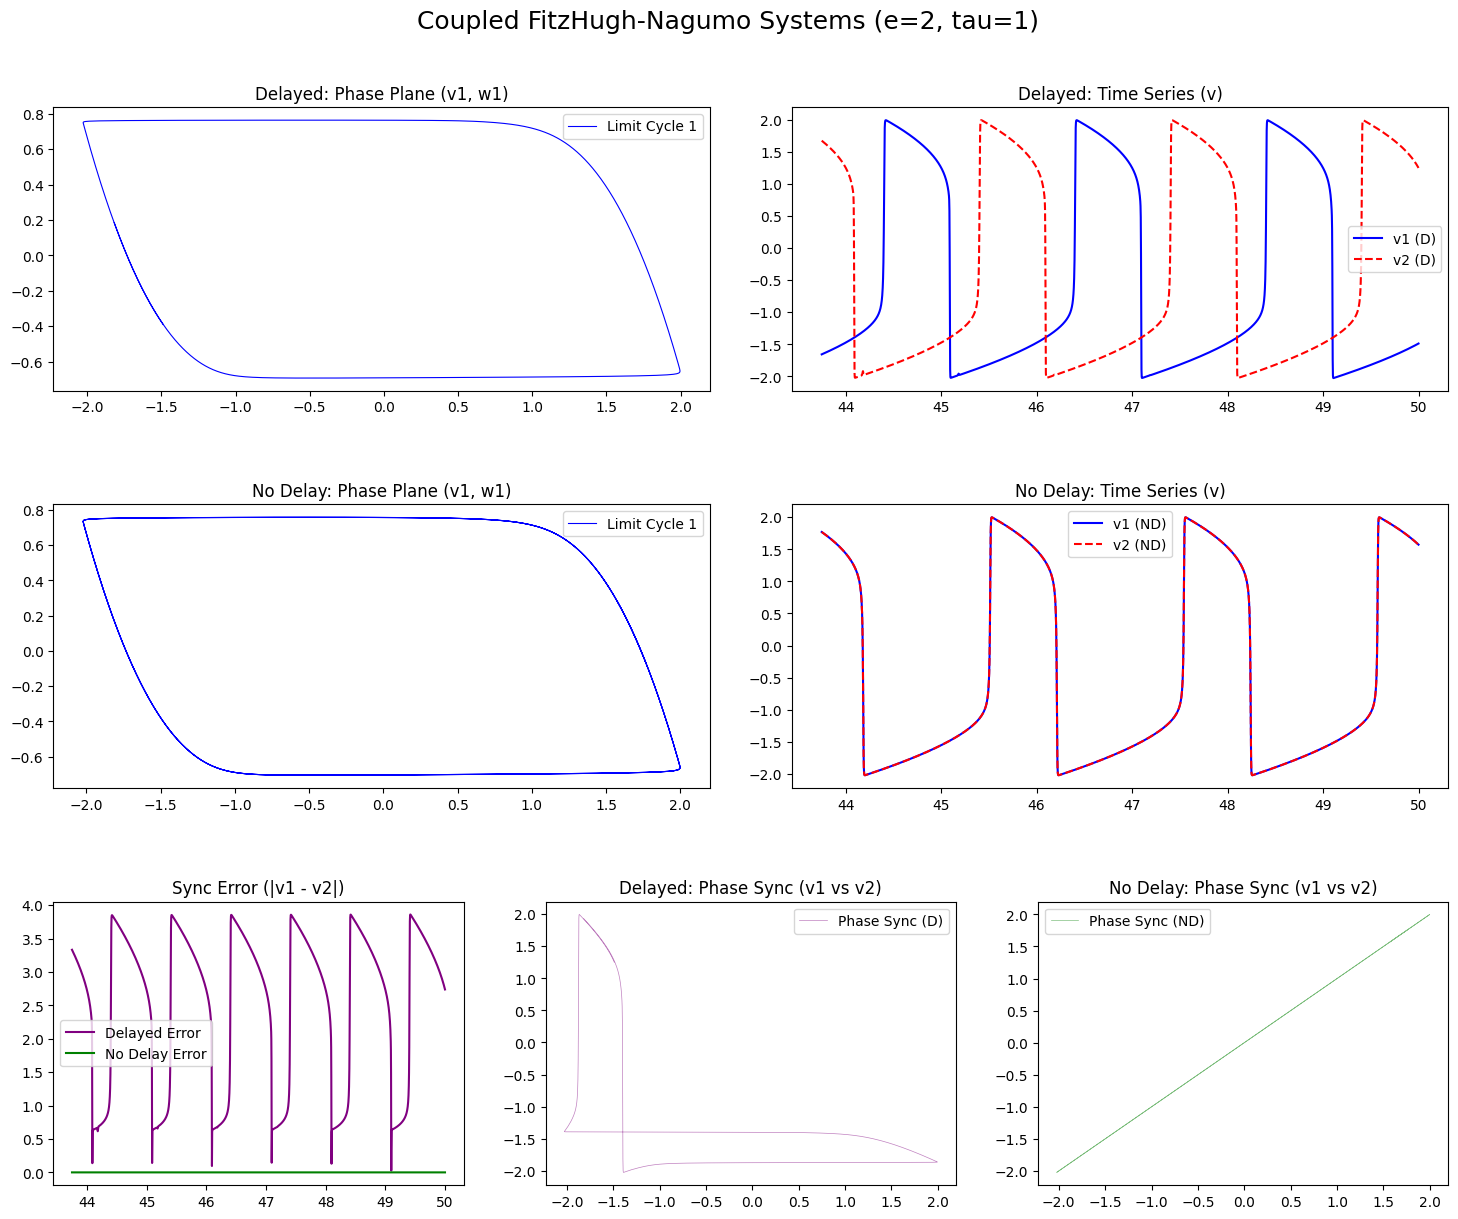


FITZ HUGH NAGUMO MODEL SIMULATION RESULTS
Final Error (Delayed): 2.739327
Final Error (No Delay): 0.000000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Parameters for FitzHugh-Nagumo System
# ==========================================
a = 0.5

eps=0.005

# Coupling and Time parameters
e = 2# Coupling strength
t0 = 0
tf = 50
N = 40000
h = (tf - t0) / N
tau = 1  # Time delay (tau)
time_delaysteps = int(tau / h)

# ==========================================
# 2. Derivative Functions
# ==========================================

def dv_dt(v, w, v_delayed, e_val):
    # Coupling is applied to the voltage variable
    return (v - (v**3)/3 - w  + e_val * (v_delayed - v))/eps

def dw_dt(v, w):
    return  (v + a )

# ==========================================
# 3. Helper Functions
# ==========================================

def get_delayed_value(history, delay_steps, current_idx):
    idx = current_idx - delay_steps
    return history[idx] if idx >= 0 else history[0]

# ==========================================
# 4. RK4 Solver
# ==========================================

def simulate_fhn(with_delay=True, v10=0.1, w10=0.1, v20=-0.1, w20=0.1):
    v1_h, w1_h = [v10], [w10]
    v2_h, w2_h = [v20], [w20]
    t_h = [t0]

    v1, w1 = v10, w10
    v2, w2 = v20, w20
    t = t0

    for i in range(N):
        if with_delay:
            v1_del = get_delayed_value(v1_h, time_delaysteps, i)
            v2_del = get_delayed_value(v2_h, time_delaysteps, i)
        else:
            v1_del, v2_del = v1, v2

        def derivs(cv1, cw1, cv2, cw2):
            dot_v1 = dv_dt(cv1, cw1, v2_del, e)
            dot_w1 = dw_dt(cv1, cw1)
            dot_v2 = dv_dt(cv2, cw2, v1_del, e)
            dot_w2 = dw_dt(cv2, cw2)
            return np.array([dot_v1, dot_w1, dot_v2, dot_w2])

        k1 = h * derivs(v1, w1, v2, w2)
        k2 = h * derivs(*(np.array([v1, w1, v2, w2]) + k1/2))
        k3 = h * derivs(*(np.array([v1, w1, v2, w2]) + k2/2))
        k4 = h * derivs(*(np.array([v1, w1, v2, w2]) + k3))

        step = (k1 + 2*k2 + 2*k3 + k4) / 6
        v1 += step[0]; w1 += step[1]
        v2 += step[2]; w2 += step[3]
        t += h

        v1_h.append(v1); w1_h.append(w1)
        v2_h.append(v2); w2_h.append(w2)
        t_h.append(t)

    return map(np.array, [v1_h, w1_h, v2_h, w2_h, t_h])

# ==========================================
# 5. Execution & Plotting
# ==========================================

# Run simulations
v1_d, w1_d, v2_d, w2_d, t_d = simulate_fhn(with_delay=True)
v1_n, w1_n, v2_n, w2_n, t_n = simulate_fhn(with_delay=False)

# Errors
err_d = np.abs(v1_d - v2_d)
err_n = np.abs(v1_n - v2_n)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 6) # Using 6 as a common denominator for 2 and 3 columns
plt.subplots_adjust(hspace=0.4, wspace=0.5)

# --- Row 1: With Delay (2 Figures) ---
ax1 = fig.add_subplot(gs[0, 0:3]) # Takes up first half of row 1
ax1.plot(v1_d[38000:], w1_d[38000:], 'b', lw=0.8, label='Limit Cycle 1')
ax1.set_title('Delayed: Phase Plane (v1, w1)')
ax1.legend()

ax2 = fig.add_subplot(gs[0, 3:6]) # Takes up second half of row 1
ax2.plot(t_d[35000:], v1_d[35000:], 'b', label='v1 (D)')
ax2.plot(t_d[35000:], v2_d[35000:], 'r--', label='v2 (D)')
ax2.set_title('Delayed: Time Series (v)')
ax2.legend()

# --- Row 2: No Delay (2 Figures) ---
ax3 = fig.add_subplot(gs[1, 0:3])
ax3.plot(v1_n[35000:], w1_n[35000:], 'b', lw=0.8, label='Limit Cycle 1')
ax3.set_title('No Delay: Phase Plane (v1, w1)')
ax3.legend()

ax4 = fig.add_subplot(gs[1, 3:6])
ax4.plot(t_n[35000:], v1_n[35000:], 'b', label='v1 (ND)')
ax4.plot(t_n[35000:], v2_n[35000:], 'r--', label='v2 (ND)')
ax4.set_title('No Delay: Time Series (v)')
ax4.legend()

# --- Row 3: Comparison (3 Figures) ---
ax5 = fig.add_subplot(gs[2, 0:2]) # Takes up 1/3 of row 3
ax5.plot(t_d[35000:], err_d[35000:], 'purple', label='Delayed Error')
ax5.plot(t_n[35000:], err_n[35000:], 'green', label='No Delay Error')
ax5.set_title('Sync Error (|v1 - v2|)')
ax5.legend()

ax6 = fig.add_subplot(gs[2, 2:4]) # Takes up middle 1/3 of row 3
ax6.plot(v1_d[38000:], v2_d[38000:], 'purple', lw=0.5, alpha=0.5, label='Phase Sync (D)')
ax6.set_title('Delayed: Phase Sync (v1 vs v2)')
ax6.legend()

ax7 = fig.add_subplot(gs[2, 4:6]) # Takes up last 1/3 of row 3
ax7.plot(v1_n[35000:], v2_n[35000:], 'green', lw=0.5, alpha=0.5, label='Phase Sync (ND)')
ax7.set_title('No Delay: Phase Sync (v1 vs v2)')
ax7.legend()

plt.suptitle(f"Coupled FitzHugh-Nagumo Systems (e={e}, tau={tau})", fontsize=18, y=0.95)
plt.show()
# Statistics
print("\n" + "="*60)
print("FITZ HUGH NAGUMO MODEL SIMULATION RESULTS")
print("="*60)
print(f"Final Error (Delayed): {err_d[-1]:.6f}")
print(f"Final Error (No Delay): {err_n[-1]:.6f}")

Computing parameter space maps for FitzHugh-Nagumo system...
Coupling range: 0.10 to 5.00
Delay range: 0.000 to 5.000
Total simulations: 1800
Progress: 100/900 (11.1%)
Progress: 200/900 (22.2%)
Progress: 300/900 (33.3%)
Progress: 400/900 (44.4%)
Progress: 500/900 (55.6%)
Progress: 600/900 (66.7%)
Progress: 700/900 (77.8%)
Progress: 800/900 (88.9%)
Progress: 900/900 (100.0%)
Simulation complete!


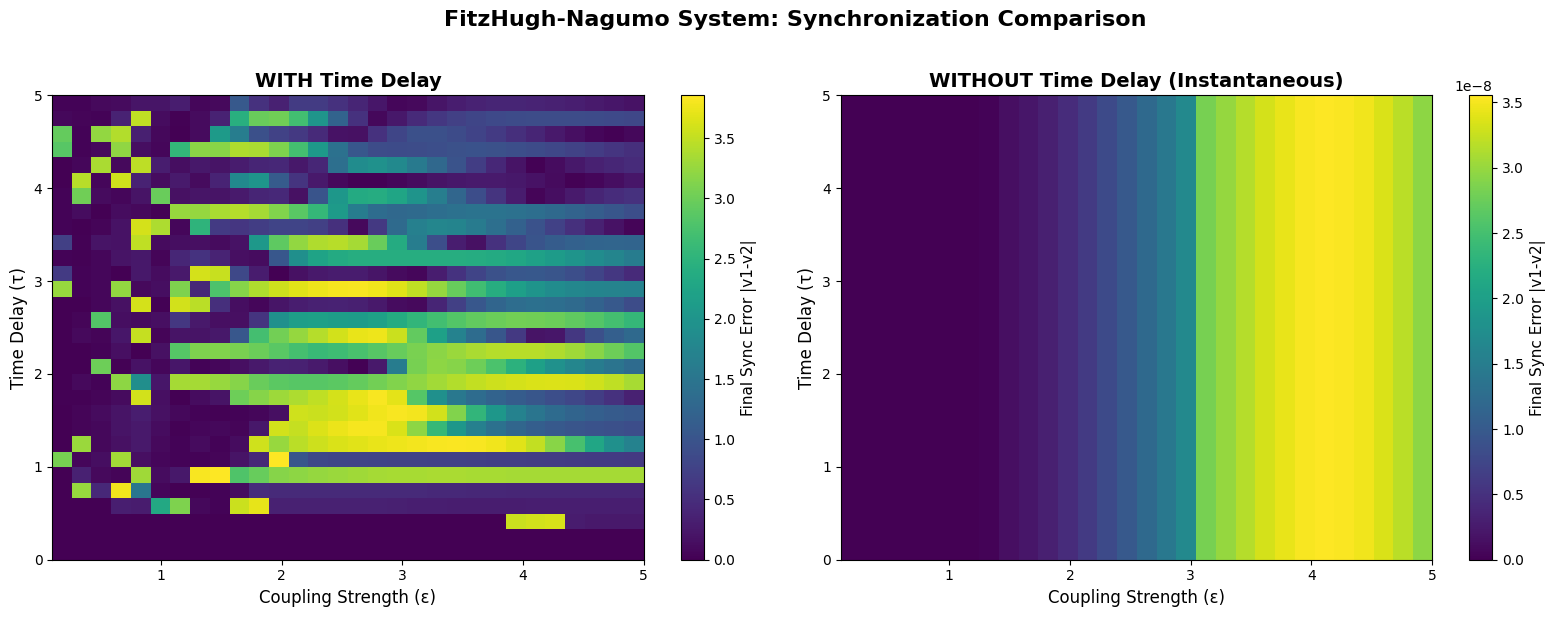


FITZHUGH-NAGUMO SYSTEM - DELAYED vs NON-DELAYED COMPARISON

WITH TIME DELAY:
  Minimum sync error: 0.0000
  Maximum sync error: 3.8552
  Mean sync error: 1.2400

WITHOUT TIME DELAY (Instantaneous):
  Minimum sync error: 0.0000
  Maximum sync error: 0.0000
  Mean sync error: 0.0000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters for FitzHugh-Nagumo System
# ==========================================
a = 0.5
eps = 0.005

t0 = 0
tf = 50
N = 40000
h = (tf - t0) / N

# ==========================================
# Derivative Functions
# ==========================================

def dv_dt(v, w, v_delayed, e_val):
    return (v - (v**3)/3 - w + e_val * (v_delayed - v)) / eps

def dw_dt(v, w):
    return (v + a)

# ==========================================
# Helper Functions
# ==========================================

def get_delayed_value(history, delay_steps, current_idx):
    idx = current_idx - delay_steps
    return history[idx] if idx >= 0 else history[0]

# ==========================================
# RK4 Solver with Time Delay
# ==========================================

def rk4_with_delay(t0, v10, w10, v20, w20, time_delaysteps, e):
    v1_h, w1_h = [v10], [w10]
    v2_h, w2_h = [v20], [w20]

    v1, w1 = v10, w10
    v2, w2 = v20, w20

    for i in range(N):
        v1_del = get_delayed_value(v1_h, time_delaysteps, i)
        v2_del = get_delayed_value(v2_h, time_delaysteps, i)

        def derivs(cv1, cw1, cv2, cw2):
            dot_v1 = dv_dt(cv1, cw1, v2_del, e)
            dot_w1 = dw_dt(cv1, cw1)
            dot_v2 = dv_dt(cv2, cw2, v1_del, e)
            dot_w2 = dw_dt(cv2, cw2)
            return np.array([dot_v1, dot_w1, dot_v2, dot_w2])

        k1 = h * derivs(v1, w1, v2, w2)
        k2 = h * derivs(*(np.array([v1, w1, v2, w2]) + k1/2))
        k3 = h * derivs(*(np.array([v1, w1, v2, w2]) + k2/2))
        k4 = h * derivs(*(np.array([v1, w1, v2, w2]) + k3))

        step = (k1 + 2*k2 + 2*k3 + k4) / 6
        v1 += step[0]; w1 += step[1]
        v2 += step[2]; w2 += step[3]

        v1_h.append(v1); w1_h.append(w1)
        v2_h.append(v2); w2_h.append(w2)

    return np.array(v1_h), np.array(w1_h), np.array(v2_h), np.array(w2_h)

# RK4 method without time delay (instantaneous)
def rk4_no_delay(t0, v10, w10, v20, w20, e):
    v1_h, w1_h = [v10], [w10]
    v2_h, w2_h = [v20], [w20]

    v1, w1 = v10, w10
    v2, w2 = v20, w20

    for i in range(N):
        v1_del = v1
        v2_del = v2

        def derivs(cv1, cw1, cv2, cw2):
            dot_v1 = dv_dt(cv1, cw1, v2_del, e)
            dot_w1 = dw_dt(cv1, cw1)
            dot_v2 = dv_dt(cv2, cw2, v1_del, e)
            dot_w2 = dw_dt(cv2, cw2)
            return np.array([dot_v1, dot_w1, dot_v2, dot_w2])

        k1 = h * derivs(v1, w1, v2, w2)
        k2 = h * derivs(*(np.array([v1, w1, v2, w2]) + k1/2))
        k3 = h * derivs(*(np.array([v1, w1, v2, w2]) + k2/2))
        k4 = h * derivs(*(np.array([v1, w1, v2, w2]) + k3))

        step = (k1 + 2*k2 + 2*k3 + k4) / 6
        v1 += step[0]; w1 += step[1]
        v2 += step[2]; w2 += step[3]

        v1_h.append(v1); w1_h.append(w1)
        v2_h.append(v2); w2_h.append(w2)

    return np.array(v1_h), np.array(w1_h), np.array(v2_h), np.array(w2_h)

# ==========================================
# Initial Conditions
# ==========================================
v10, w10 = 0.1, 0.1
v20, w20 = -0.1, 0.1

# ==========================================
# Parameter Ranges
# ==========================================
coupling_values = np.linspace(0.1, 5.0, 30)  # Coupling strength
delay_values = np.linspace(0.0, 5.0, 30)     # Time delay

# Initialize synchronization error matrices
sync_error_delay_map = np.zeros((len(delay_values), len(coupling_values)))
sync_error_no_delay_map = np.zeros((len(delay_values), len(coupling_values)))

print("Computing parameter space maps for FitzHugh-Nagumo system...")
print(f"Coupling range: {coupling_values[0]:.2f} to {coupling_values[-1]:.2f}")
print(f"Delay range: {delay_values[0]:.3f} to {delay_values[-1]:.3f}")
print(f"Total simulations: {2 * len(coupling_values) * len(delay_values)}")

# ==========================================
# Compute Synchronization Error Map
# ==========================================
total_sims = len(coupling_values) * len(delay_values)
sim_count = 0

for i, tau in enumerate(delay_values):
    for j, e in enumerate(coupling_values):
        sim_count += 1
        if sim_count % 100 == 0:
            print(f"Progress: {sim_count}/{total_sims} ({100*sim_count/total_sims:.1f}%)")

        time_delaysteps = int(tau / h)

        # Run simulation WITH delay
        v1_d, w1_d, v2_d, w2_d = rk4_with_delay(t0, v10, w10, v20, w20, time_delaysteps, e)
        sync_error_delay_map[i, j] = np.abs(v1_d[-1] - v2_d[-1])

        # Run simulation WITHOUT delay
        v1_n, w1_n, v2_n, w2_n = rk4_no_delay(t0, v10, w10, v20, w20, e)
        sync_error_no_delay_map[i, j] = np.abs(v1_n[-1] - v2_n[-1])

print("Simulation complete!")

# ==========================================
# Visualization - Side by side comparison
# ==========================================
fig = plt.figure(figsize=(16, 6))

# 1. With Time Delay
ax1 = plt.subplot(1, 2, 1)
im1 = ax1.imshow(sync_error_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax1.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax1.set_ylabel('Time Delay (τ)', fontsize=12)
ax1.set_title('WITH Time Delay', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('Final Sync Error |v1-v2|', fontsize=11)

# 2. Without Time Delay (instantaneous)
ax2 = plt.subplot(1, 2, 2)
im2 = ax2.imshow(sync_error_no_delay_map, aspect='auto', origin='lower', cmap='viridis',
                 extent=[coupling_values[0], coupling_values[-1],
                        delay_values[0], delay_values[-1]])
ax2.set_xlabel('Coupling Strength (ε)', fontsize=12)
ax2.set_ylabel('Time Delay (τ)', fontsize=12)
ax2.set_title('WITHOUT Time Delay (Instantaneous)', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Final Sync Error |v1-v2|', fontsize=11)

plt.suptitle('FitzHugh-Nagumo System: Synchronization Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# Statistics
# ==========================================
print("\n" + "="*70)
print("FITZHUGH-NAGUMO SYSTEM - DELAYED vs NON-DELAYED COMPARISON")
print("="*70)

print(f"\nWITH TIME DELAY:")
print(f"  Minimum sync error: {np.min(sync_error_delay_map):.4f}")
print(f"  Maximum sync error: {np.max(sync_error_delay_map):.4f}")
print(f"  Mean sync error: {np.mean(sync_error_delay_map):.4f}")


print(f"\nWITHOUT TIME DELAY (Instantaneous):")
print(f"  Minimum sync error: {np.min(sync_error_no_delay_map):.4f}")
print(f"  Maximum sync error: {np.max(sync_error_no_delay_map):.4f}")
print(f"  Mean sync error: {np.mean(sync_error_no_delay_map):.4f}")


print("\n" + "="*70)